In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/saurabhshahane/road-traffic-accidents/RTA Dataset.csv
/kaggle/input/datasets/saurabhshahane/road-traffic-accidents/cleaned.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

# Pre-Processing

In [3]:
df = pd.read_csv('/kaggle/input/datasets/saurabhshahane/road-traffic-accidents/RTA Dataset.csv')
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
df.shape

(12316, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [6]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
df.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Cause_of_a


--- Distribution for Time ---
Time
15:30:00    0.974342
17:10:00    0.893147
18:30:00    0.836310
11:30:00    0.803832
17:00:00    0.795713
              ...   
2:48:00     0.008120
19:34:00    0.008120
14:48:00    0.008120
19:18:00    0.008120
2:47:00     0.008120
Name: proportion, Length: 1074, dtype: float64


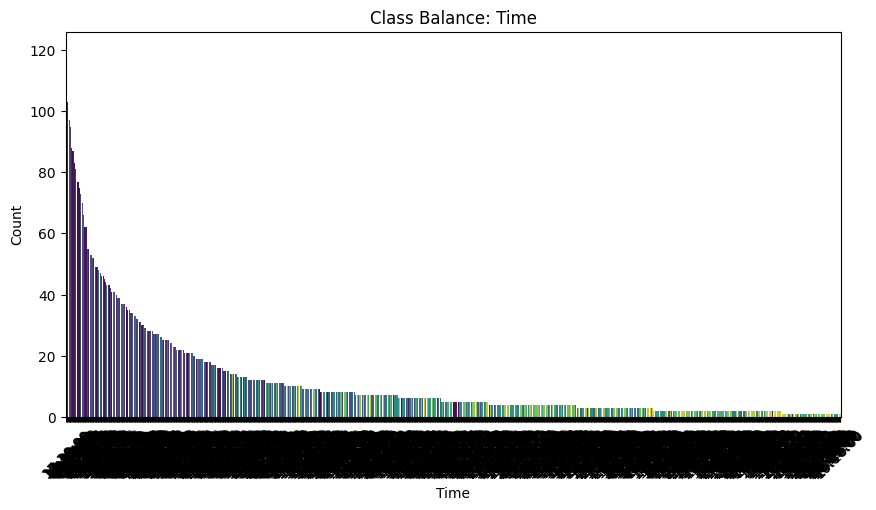


--- Distribution for Day_of_week ---
Day_of_week
Friday       16.571939
Thursday     15.029230
Wednesday    14.939916
Tuesday      14.371549
Monday       13.648912
Saturday     13.527119
Sunday       11.911335
Name: proportion, dtype: float64


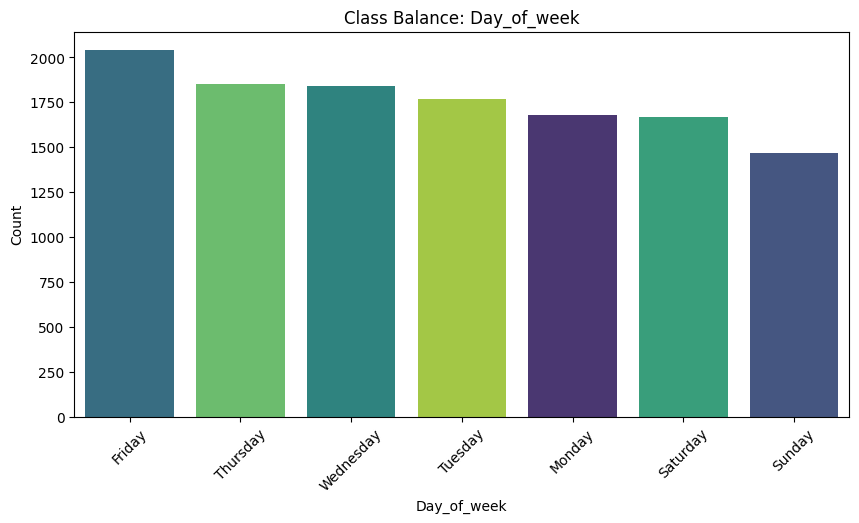


--- Distribution for Age_band_of_driver ---
Age_band_of_driver
18-30       34.678467
31-50       33.184475
Over 51     12.869438
Unknown     12.569016
Under 18     6.698603
Name: proportion, dtype: float64


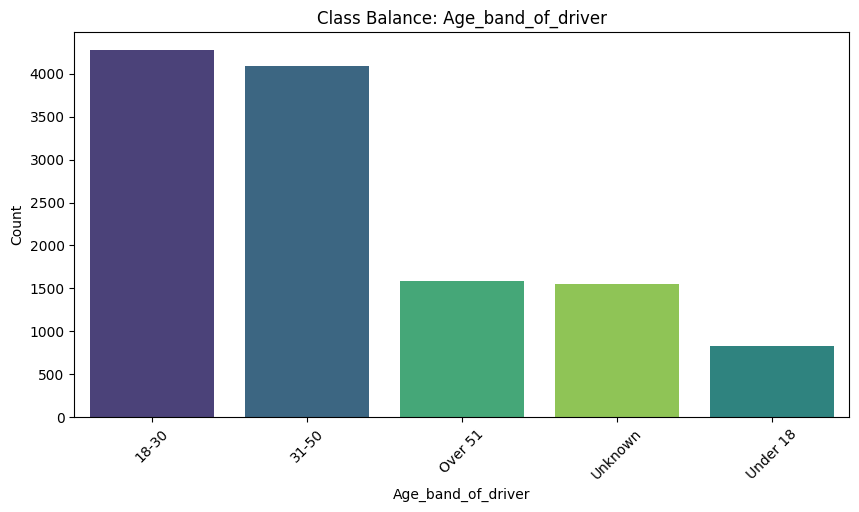


--- Distribution for Sex_of_driver ---
Sex_of_driver
Male       92.862943
Female      5.691783
Unknown     1.445274
Name: proportion, dtype: float64


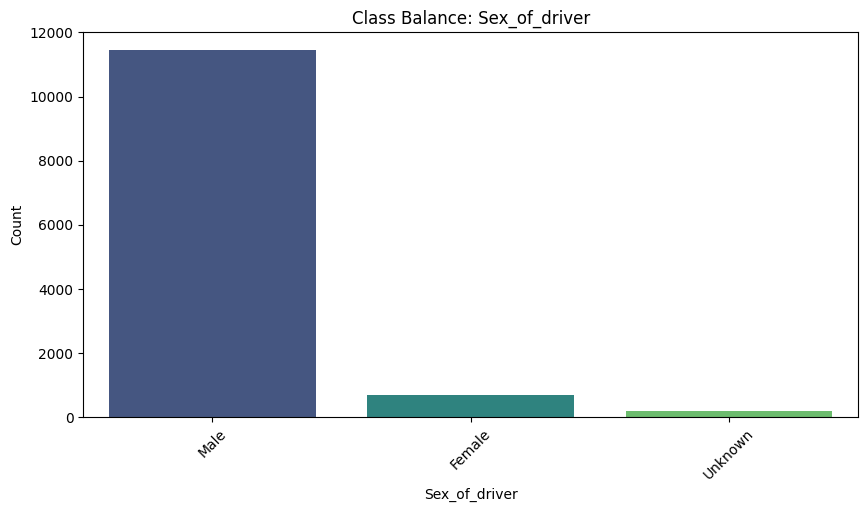


--- Distribution for Educational_level ---
Educational_level
Junior high school    61.862618
Elementary school     17.562520
High school            9.012666
Unknown                6.828516
Above high school      2.939266
Writing & reading      1.429035
Illiterate             0.365378
Name: proportion, dtype: float64


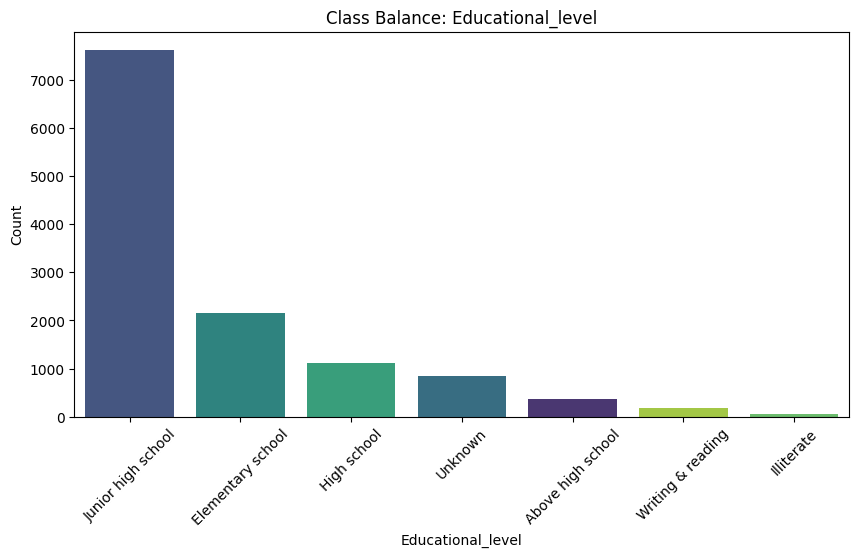


--- Distribution for Vehicle_driver_relation ---
Vehicle_driver_relation
Employee    78.166613
Owner       16.019812
Unknown      4.814875
Other        0.998701
Name: proportion, dtype: float64


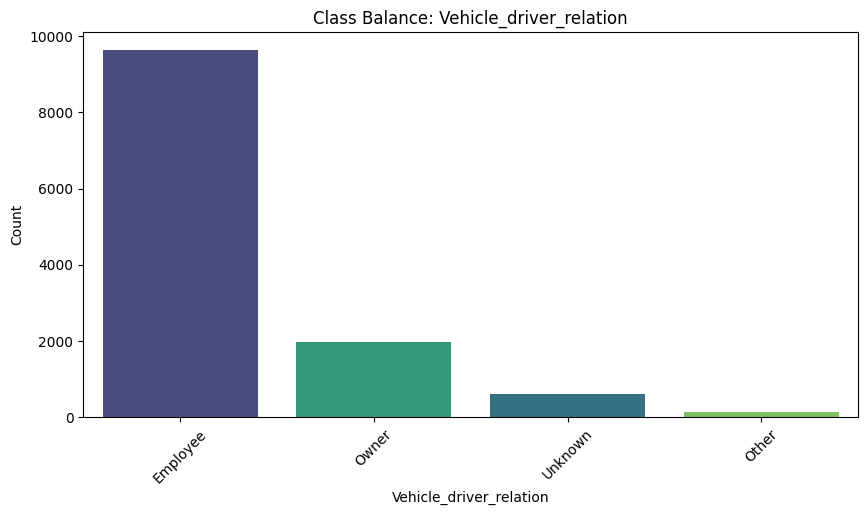


--- Distribution for Driving_experience ---
Driving_experience
5-10yr        27.305943
2-5yr         21.216304
Above 10yr    18.366353
1-2yr         14.257876
Below 1yr     10.896395
Unknown        6.731082
No Licence     0.958103
unknown        0.267944
Name: proportion, dtype: float64


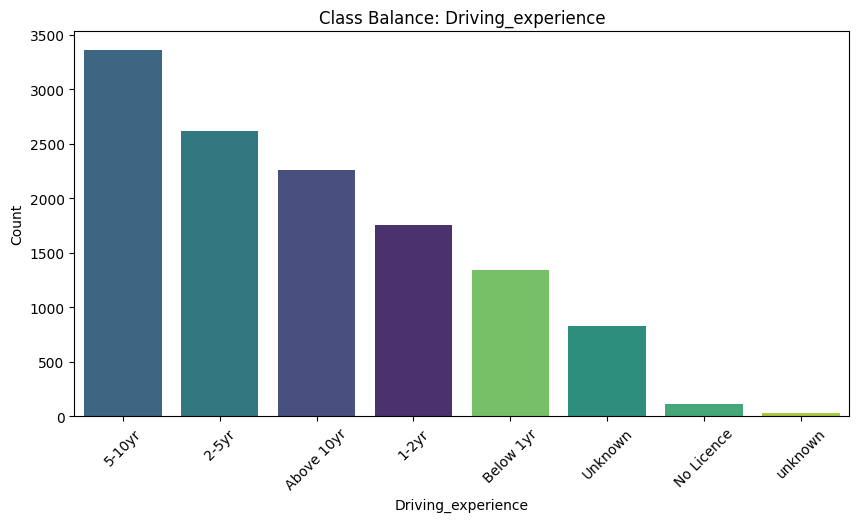


--- Distribution for Type_of_vehicle ---
Type_of_vehicle
Automobile              26.023059
Lorry (41?100Q)         17.749269
Other                    9.808379
Unknown                  7.713543
Pick up upto 10Q         6.584930
Public (12 seats)        5.772978
Stationwagen             5.578110
Lorry (11?40Q)           4.392660
Public (13?45 seats)     4.319584
Public (> 45 seats)      3.280286
Long lorry               3.109776
Taxi                     2.151673
Motorcycle               1.437155
Special vehicle          0.682040
Ridden horse             0.617083
Turbo                    0.373498
Bajaj                    0.235466
Bicycle                  0.170510
Name: proportion, dtype: float64


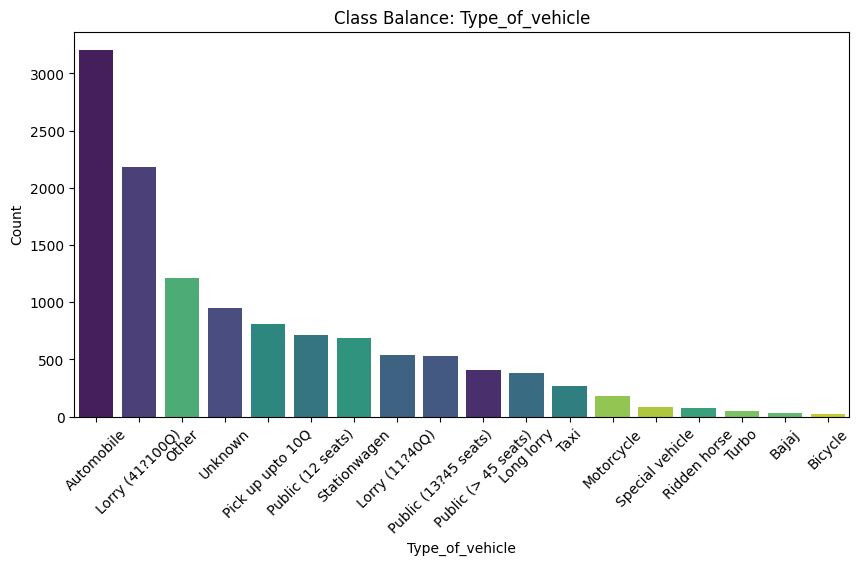


--- Distribution for Owner_of_vehicle ---
Owner_of_vehicle
Owner           84.922053
Governmental     8.452420
Unknown          3.913608
Organization     2.533290
Other            0.178629
Name: proportion, dtype: float64


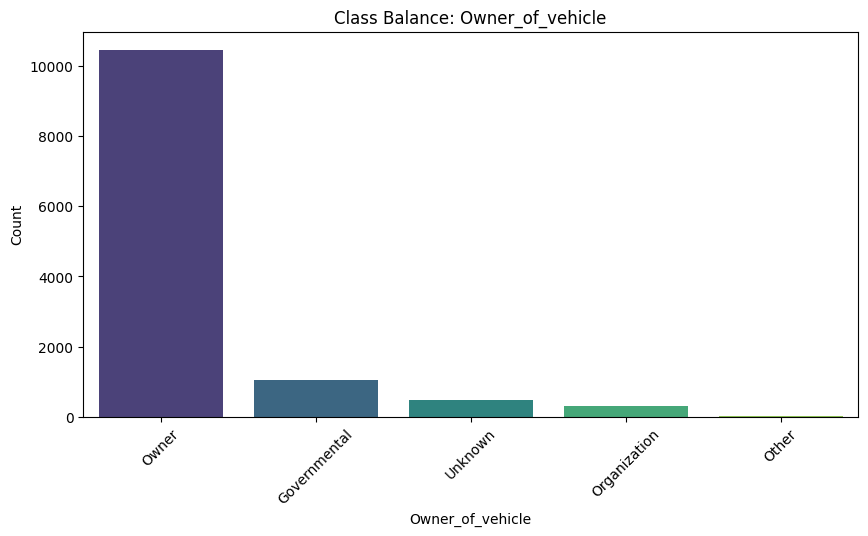


--- Distribution for Service_year_of_vehicle ---
Service_year_of_vehicle
Unknown       55.302046
2-5yrs        14.550179
Above 10yr    10.750244
5-10yrs       10.392985
1-2yr          6.714842
Below 1yr      2.289704
Name: proportion, dtype: float64


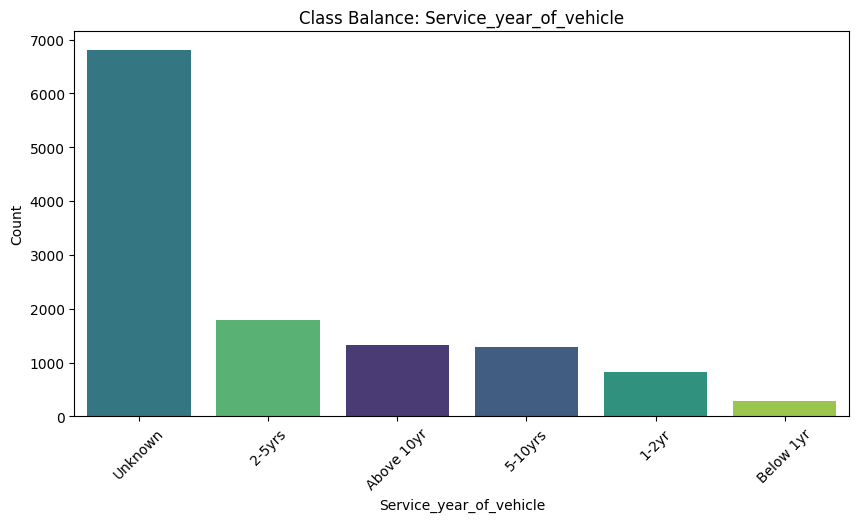


--- Distribution for Defect_of_vehicle ---
Defect_of_vehicle
No defect    63.145502
Unknown      35.945112
7             0.617083
5             0.292303
Name: proportion, dtype: float64


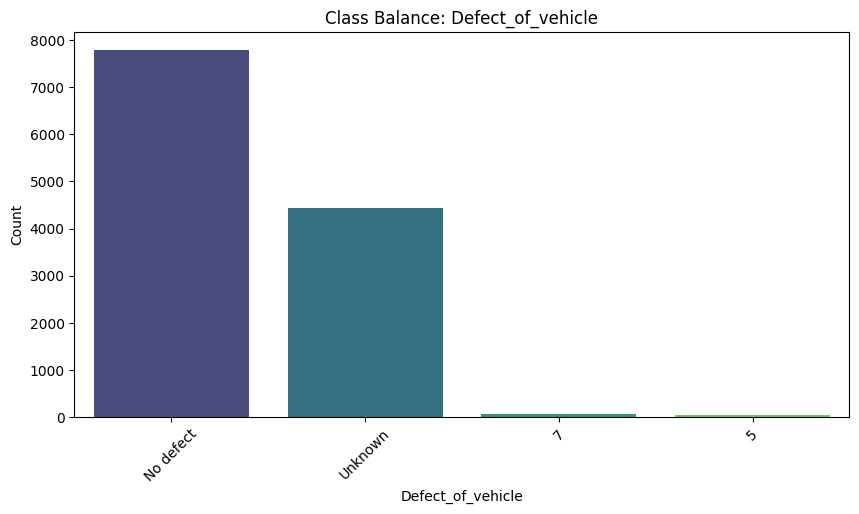


--- Distribution for Area_accident_occured ---
Area_accident_occured
Other                              31.008444
Office areas                       28.020461
Residential areas                  16.726210
 Church areas                       8.606690
 Industrial areas                   3.702501
School areas                        3.369601
  Recreational areas                2.655083
Unknown                             2.119195
 Outside rural areas                1.770055
 Hospital areas                     0.982462
  Market areas                      0.511530
Rural village areas                 0.357259
Rural village areasOffice areas     0.162390
Recreational areas                  0.008120
Name: proportion, dtype: float64


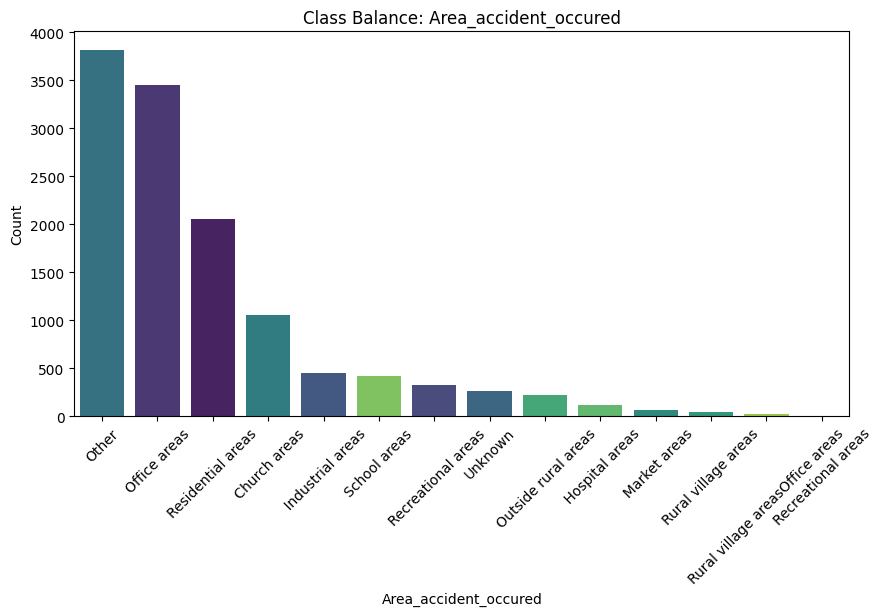


--- Distribution for Lanes_or_Medians ---
Lanes_or_Medians
Two-way (divided with broken lines road marking)    35.815200
Undivided Two way                                   30.821695
other                                               13.478402
Double carriageway (median)                          8.281910
One way                                              6.860994
Unknown                                              3.588828
Two-way (divided with solid lines road marking)      1.152972
Name: proportion, dtype: float64


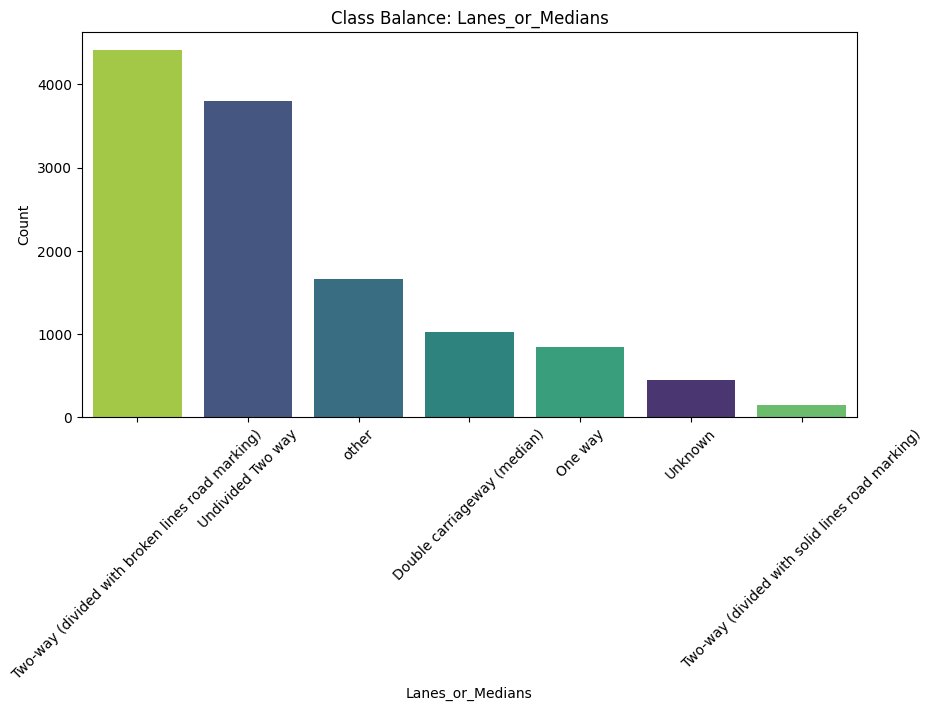


--- Distribution for Road_allignment ---
Road_allignment
Tangent road with flat terrain                   84.922053
Tangent road with mild grade and flat terrain     4.067879
Steep grade downward with mountainous terrain     3.483274
Tangent road with mountainous terrain and         3.215330
Gentle horizontal curve                           1.323482
Unknown                                           1.152972
Escarpments                                       0.917506
Sharp reverse curve                               0.462813
Tangent road with rolling terrain                 0.300422
Steep grade upward with mountainous terrain       0.154271
Name: proportion, dtype: float64


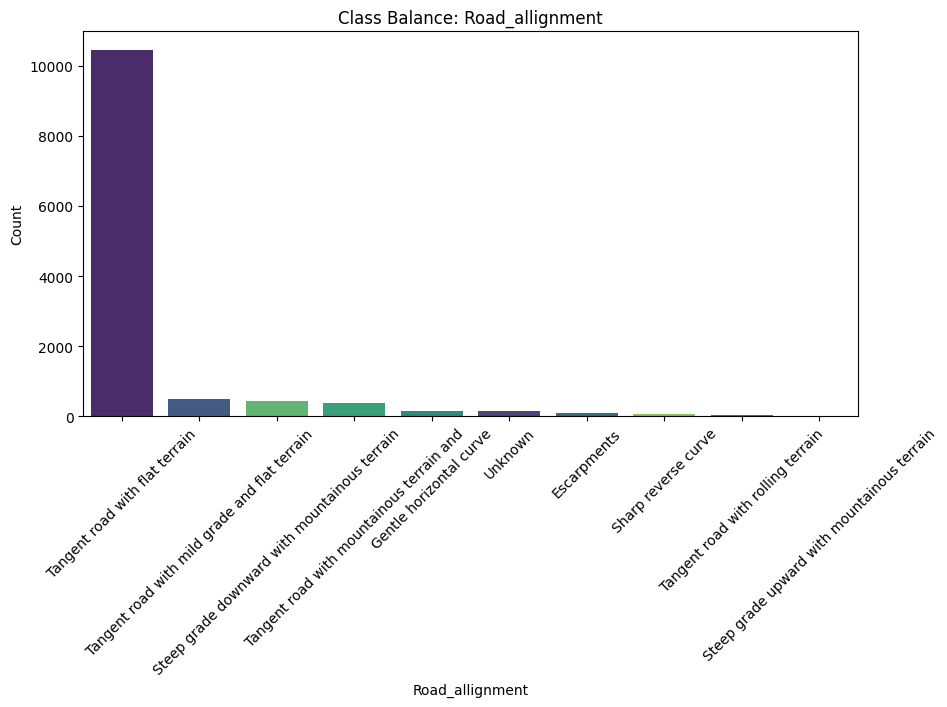


--- Distribution for Types_of_Junction ---
Types_of_Junction
Y Shape        36.886976
No junction    31.154596
Crossing       17.676194
Unknown         8.752842
Other           3.613186
O Shape         1.331601
T Shape         0.487171
X Shape         0.097434
Name: proportion, dtype: float64


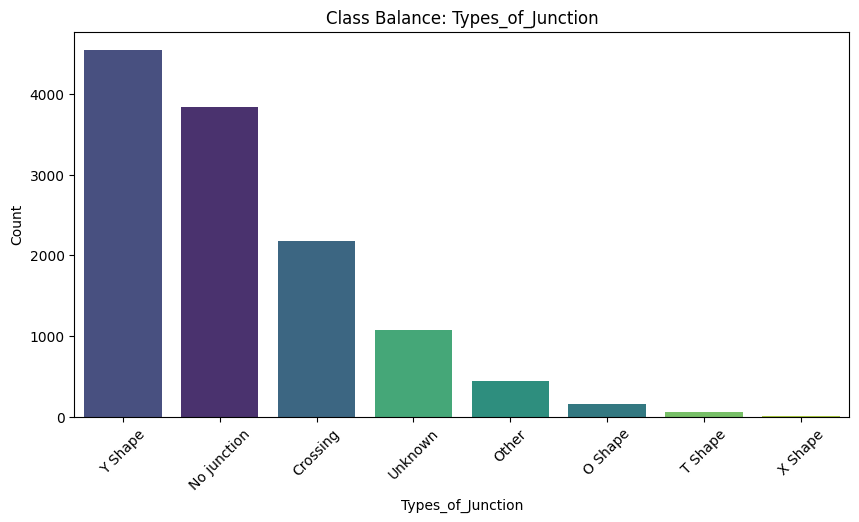


--- Distribution for Road_surface_type ---
Road_surface_type
Asphalt roads                       91.718090
Earth roads                          2.906788
Gravel roads                         1.964924
Unknown                              1.396557
Other                                1.355960
Asphalt roads with some distress     0.657681
Name: proportion, dtype: float64


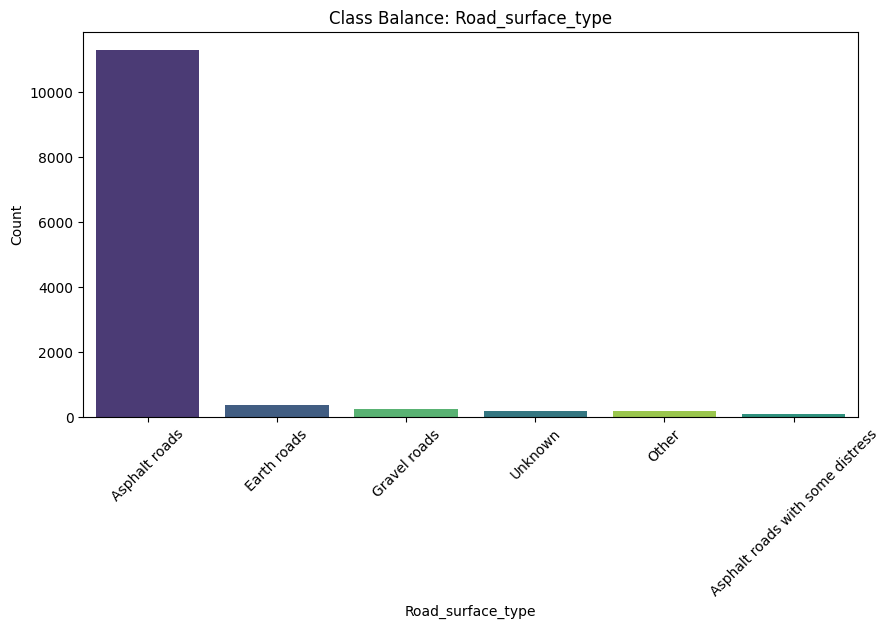


--- Distribution for Road_surface_conditions ---
Road_surface_conditions
Dry                     75.836310
Wet or damp             23.579084
Snow                     0.568366
Flood over 3cm. deep     0.016239
Name: proportion, dtype: float64


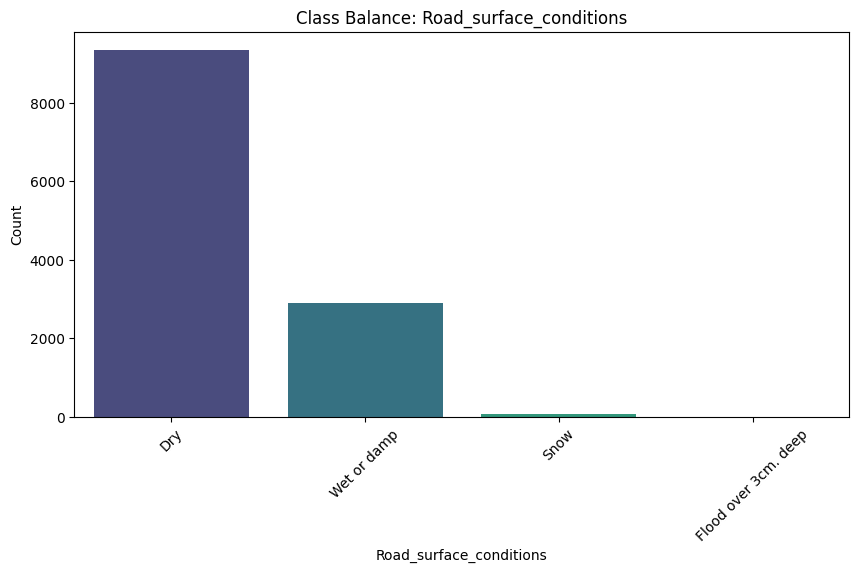


--- Distribution for Light_conditions ---
Light_conditions
Daylight                   71.435531
Darkness - lights lit      26.680741
Darkness - no lighting      1.558948
Darkness - lights unlit     0.324781
Name: proportion, dtype: float64


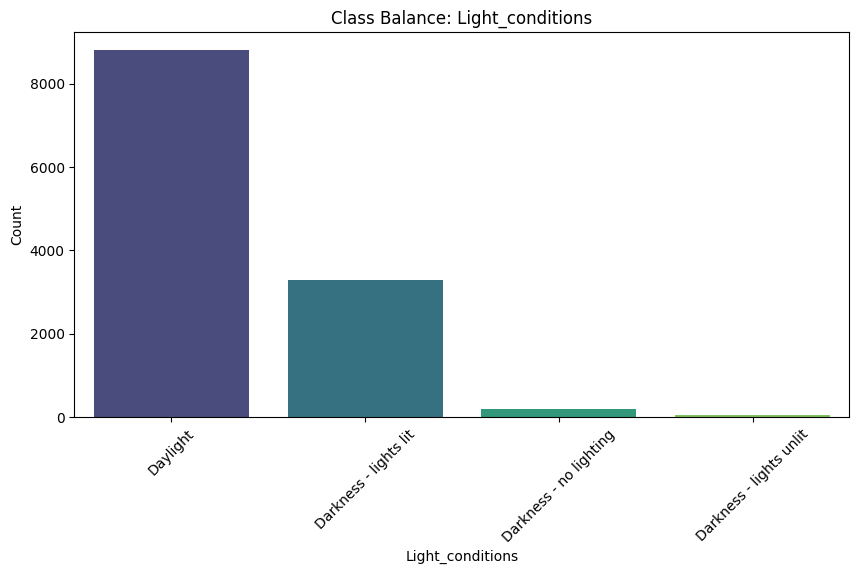


--- Distribution for Weather_conditions ---
Weather_conditions
Normal               81.706723
Raining              10.807080
Other                 2.403378
Unknown               2.370900
Cloudy                1.014940
Windy                 0.795713
Snow                  0.495291
Raining and Windy     0.324781
Fog or mist           0.081195
Name: proportion, dtype: float64


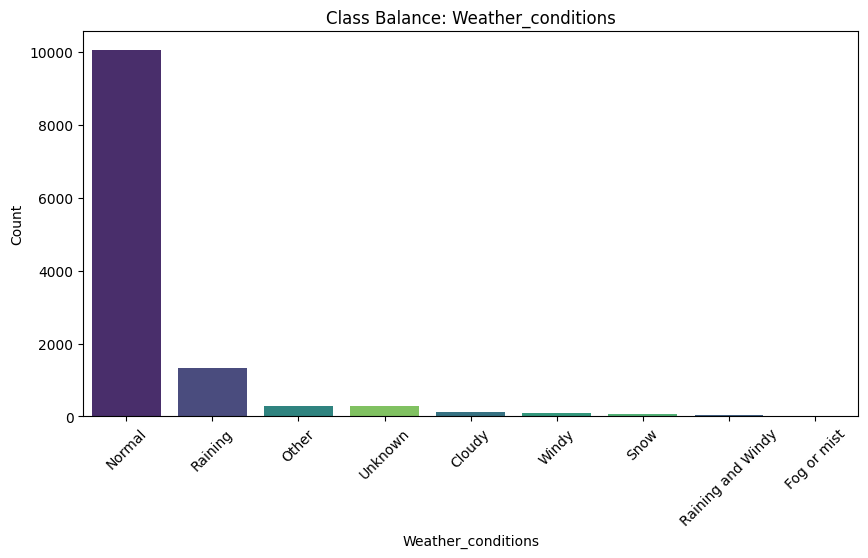


--- Distribution for Type_of_collision ---
Type_of_collision
Vehicle with vehicle collision             71.240663
Collision with roadside objects            14.501462
Collision with pedestrians                  7.275089
Rollover                                    3.223449
Collision with animals                      1.388438
Unknown                                     1.372199
Collision with roadside-parked vehicles     0.438454
Fall from vehicles                          0.276064
Other                                       0.211108
With Train                                  0.073076
Name: proportion, dtype: float64


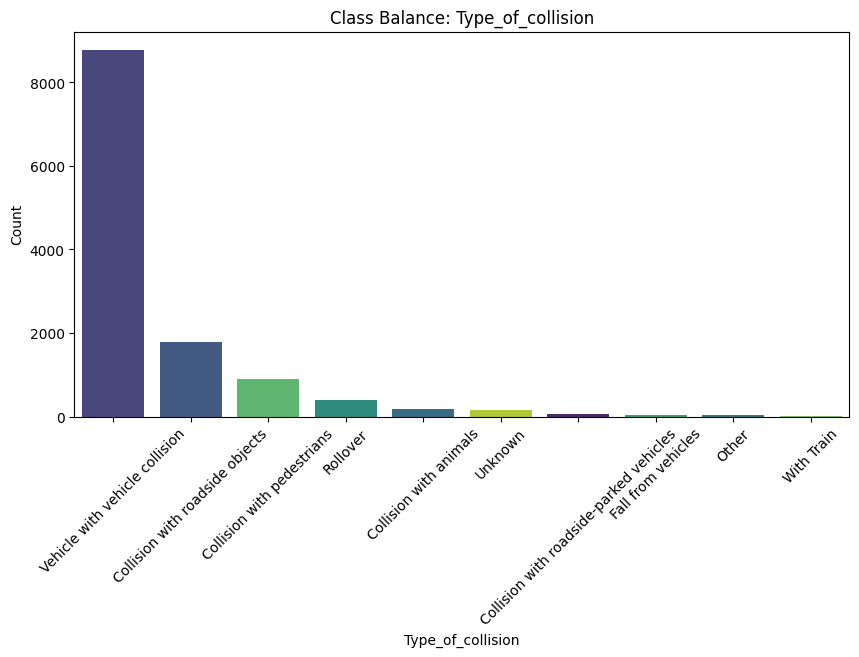


--- Distribution for Vehicle_movement ---
Vehicle_movement
Going straight         66.239039
Moving Backward         7.997727
Other                   7.607990
Reversing               4.571289
Turnover                3.970445
Unknown                 3.215330
Getting off             2.752517
Entering a junction     1.567067
Overtaking              0.779474
Stopping                0.495291
U-Turn                  0.405976
Waiting to go           0.316661
Parked                  0.081195
Name: proportion, dtype: float64


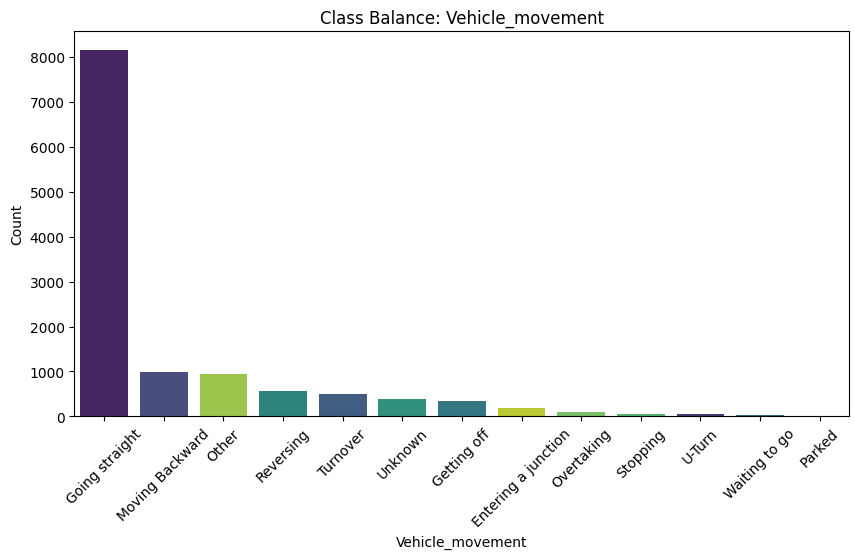


--- Distribution for Casualty_class ---
Casualty_class
Driver or rider    40.142904
na                 36.075024
Pedestrian         13.389087
Passenger          10.392985
Name: proportion, dtype: float64


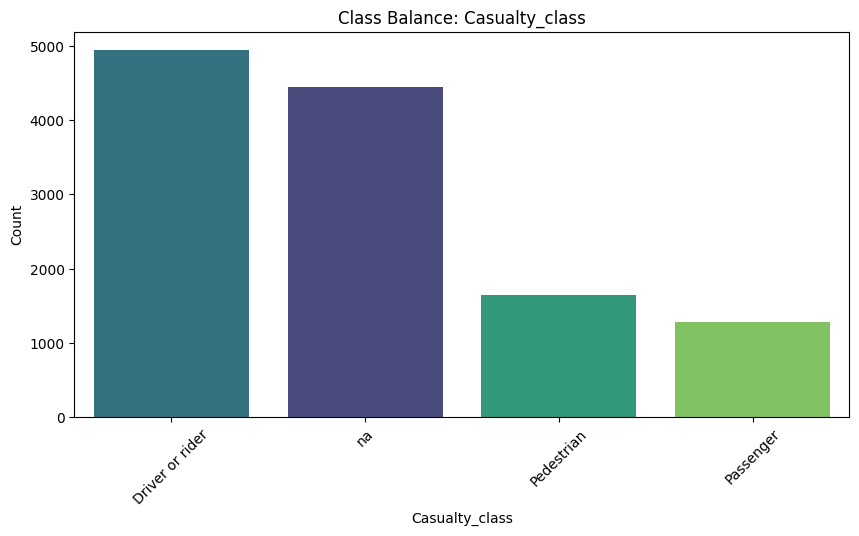


--- Distribution for Sex_of_casualty ---
Sex_of_casualty
Male      42.651835
na        36.075024
Female    21.273141
Name: proportion, dtype: float64


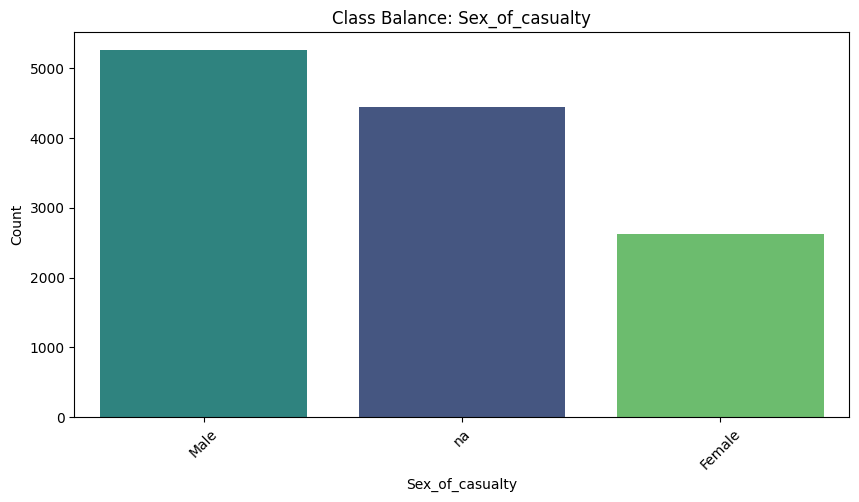


--- Distribution for Age_band_of_casualty ---
Age_band_of_casualty
na          36.075024
18-30       25.535888
31-50       19.933420
Under 18     8.403703
Over 51      8.070802
5            1.981163
Name: proportion, dtype: float64


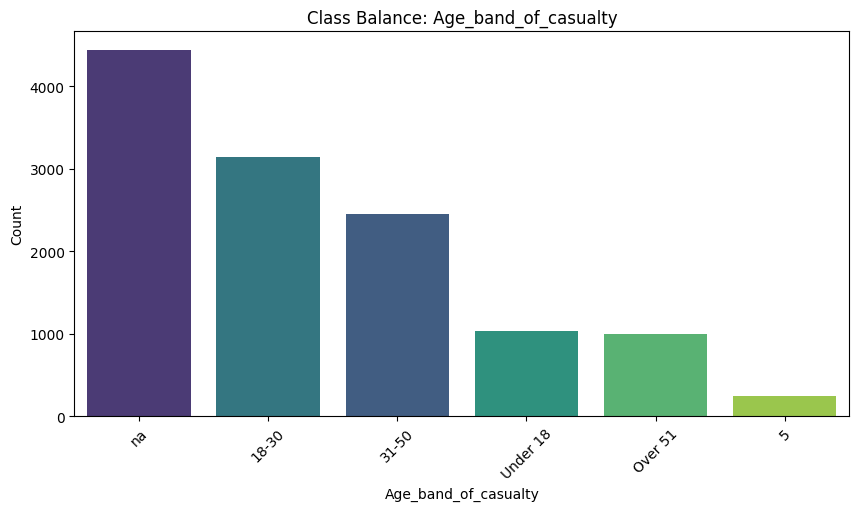


--- Distribution for Casualty_severity ---
Casualty_severity
3     57.453719
na    36.075024
2      6.260149
1      0.211108
Name: proportion, dtype: float64


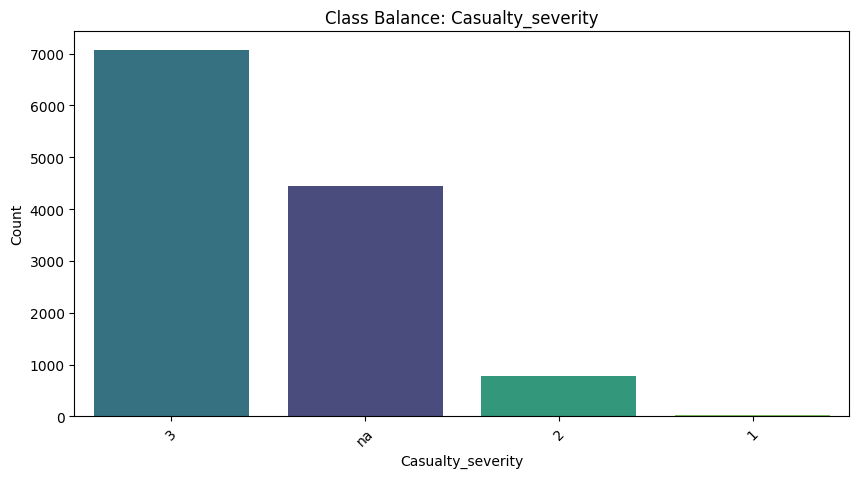


--- Distribution for Work_of_casuality ---
Work_of_casuality
Driver           47.929523
Unknown          26.120494
Self-employed    16.596297
Employee          4.490094
Other             3.759337
Student           0.836310
Unemployed        0.267944
Name: proportion, dtype: float64


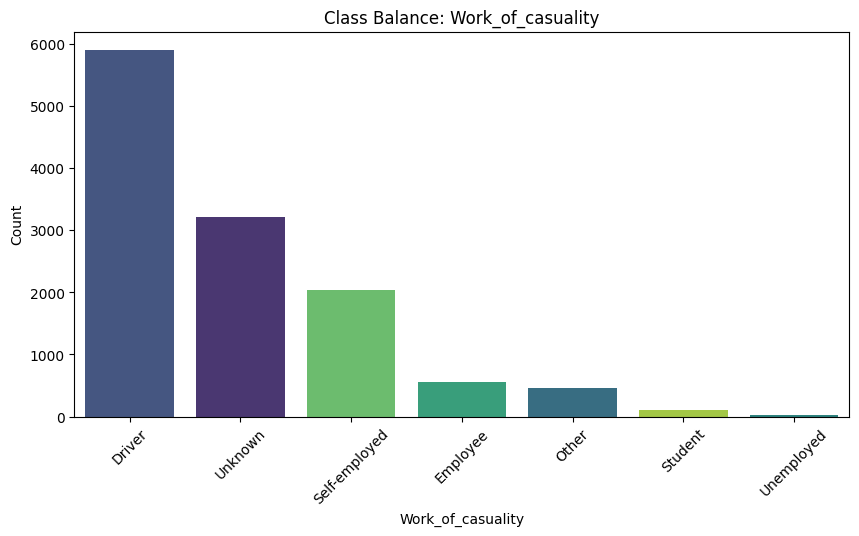


--- Distribution for Fitness_of_casuality ---
Fitness_of_casuality
Normal          78.012342
Unknown         21.394933
NormalNormal     0.154271
Deaf             0.146151
Other            0.146151
Blind            0.146151
Name: proportion, dtype: float64


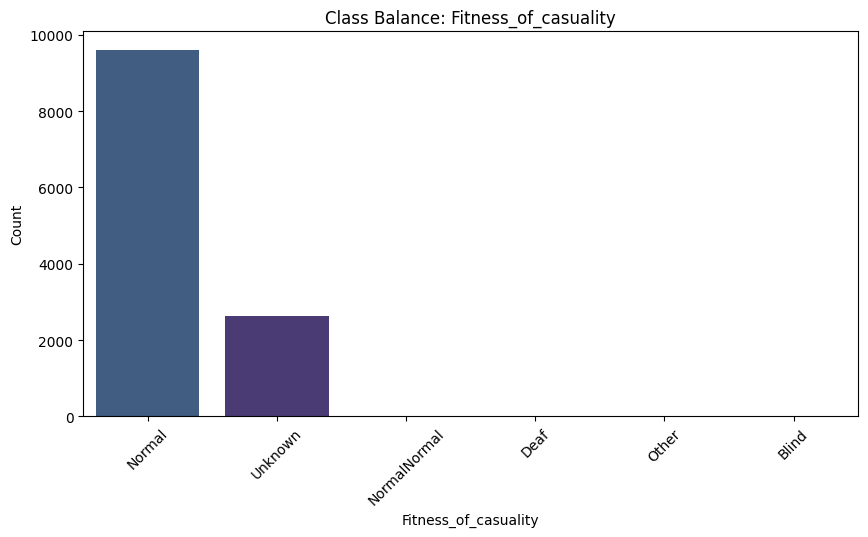


--- Distribution for Pedestrian_movement ---
Pedestrian_movement
Not a Pedestrian                                                                                                                         92.481325
Crossing from nearside - masked by parked or statioNot a Pedestrianry vehicle                                                             2.736278
Unknown or other                                                                                                                          2.379019
Crossing from driver's nearside                                                                                                           1.136733
Crossing from offside - masked by  parked or statioNot a Pedestrianry vehicle                                                             0.584605
In carriageway, statioNot a Pedestrianry - not crossing  (standing or playing)                                                            0.373498
Walking along in carriageway, back to traffic       

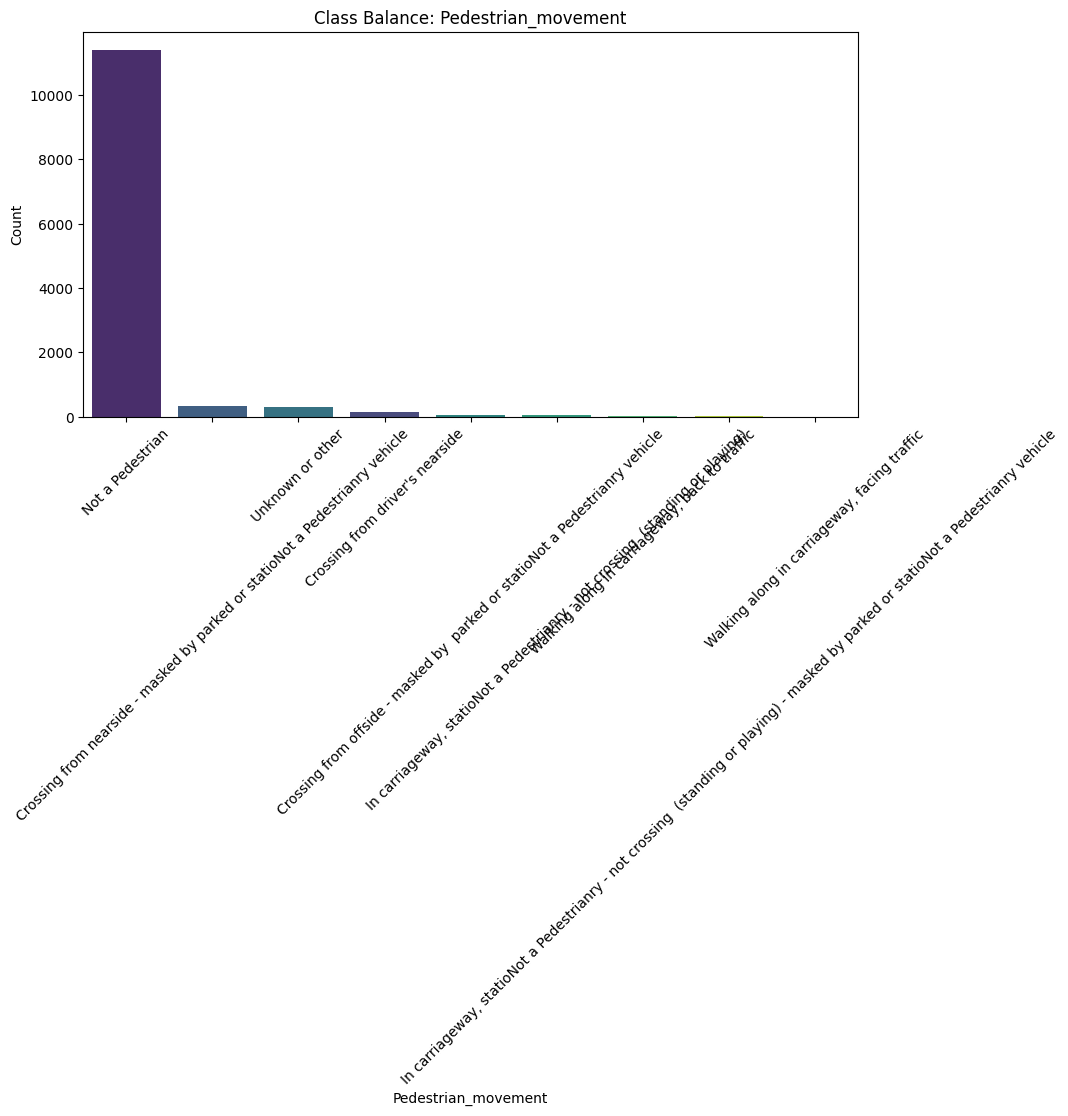


--- Distribution for Cause_of_accident ---
Cause_of_accident
No distancing                           18.374472
Changing lane to the right              14.680091
Changing lane to the left               11.960052
Driving carelessly                      11.383566
No priority to vehicle                   9.800260
Moving Backward                          9.231893
No priority to pedestrian                5.854173
Other                                    3.702501
Overtaking                               3.491393
Driving under the influence of drugs     2.760637
Driving to the left                      2.305943
Getting off the vehicle improperly       1.599545
Driving at high speed                    1.412796
Overturning                              1.209808
Turnover                                 0.633323
Overspeed                                0.495291
Overloading                              0.479052
Drunk driving                            0.219227
Improper parking                      

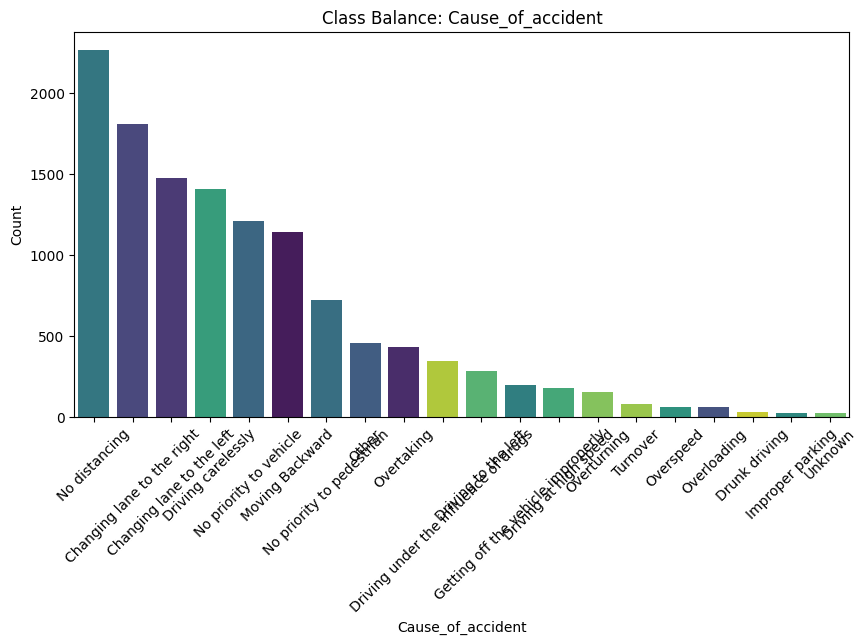


--- Distribution for Accident_severity ---
Accident_severity
Slight Injury     84.564794
Serious Injury    14.152322
Fatal injury       1.282884
Name: proportion, dtype: float64


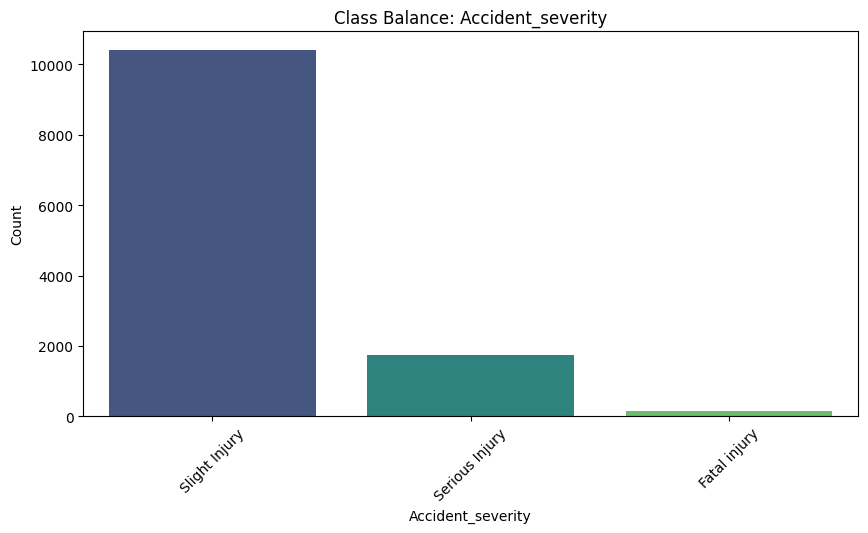

In [8]:
for cat in categorical_cols:
    print(f"\n--- Distribution for {cat} ---")
    print(df[cat].value_counts(normalize=True) * 100)

    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df, 
        x=cat, 
        hue=cat, 
        palette='viridis', 
        legend=False,
        order=df[cat].value_counts().index
    )
    
    plt.title(f'Class Balance: {cat}')
    plt.xticks(rotation=45)
    plt.xlabel(cat)
    plt.ylabel('Count')
    plt.show()


In [9]:
# processing time column
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Hour'] = df['Time'].dt.hour
df = df.drop(columns=['Time'])
df.head()

/tmp/ipykernel_24/3106641326.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1


## Replace rare categories with 'Other'

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
threshold = 0.05


for col in categorical_cols:
    series = df[col].value_counts(normalize=True)
    rare_categories = series[series < threshold].index
    #Replace rare categories with 'Other'
    if len(rare_categories) > 0:
        print(f"Grouping {len(rare_categories)} rare categories in '{col}' into 'Other'")
        df[col] = df[col].replace(rare_categories, 'Other')


Grouping 1 rare categories in 'Sex_of_driver' into 'Other'
Grouping 3 rare categories in 'Educational_level' into 'Other'
Grouping 2 rare categories in 'Vehicle_driver_relation' into 'Other'
Grouping 2 rare categories in 'Driving_experience' into 'Other'
Grouping 11 rare categories in 'Type_of_vehicle' into 'Other'
Grouping 3 rare categories in 'Owner_of_vehicle' into 'Other'
Grouping 1 rare categories in 'Service_year_of_vehicle' into 'Other'
Grouping 2 rare categories in 'Defect_of_vehicle' into 'Other'
Grouping 10 rare categories in 'Area_accident_occured' into 'Other'
Grouping 2 rare categories in 'Lanes_or_Medians' into 'Other'
Grouping 9 rare categories in 'Road_allignment' into 'Other'
Grouping 4 rare categories in 'Types_of_Junction' into 'Other'
Grouping 5 rare categories in 'Road_surface_type' into 'Other'
Grouping 2 rare categories in 'Road_surface_conditions' into 'Other'
Grouping 2 rare categories in 'Light_conditions' into 'Other'
Grouping 7 rare categories in 'Weather_co

## missing_variations merge

In [11]:
missing_variations = ['Unknown', 'unknown', 'unknown other', 'na', 'n/a', 'None']
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].replace(missing_variations, 'Unknown')

In [12]:
# remove Accident_severity of other
df = df[df['Accident_severity'] != 'Other']


--- Distribution for Day_of_week ---
Day_of_week
Friday       16.655700
Thursday     15.043593
Wednesday    14.977792
Tuesday      14.418490
Monday       13.727587
Saturday     13.398585
Sunday       11.778253
Name: proportion, dtype: float64


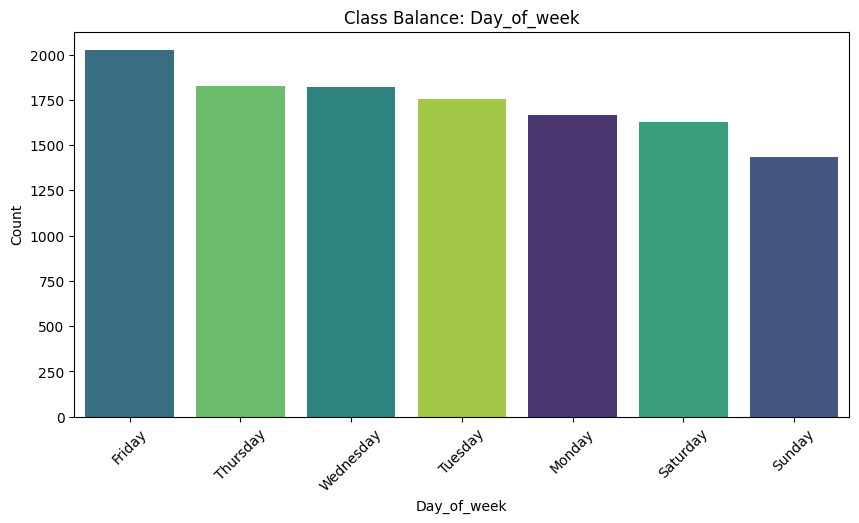


--- Distribution for Age_band_of_driver ---
Age_band_of_driver
18-30       34.619181
31-50       33.171574
Over 51     12.839283
Unknown     12.683007
Under 18     6.686955
Name: proportion, dtype: float64


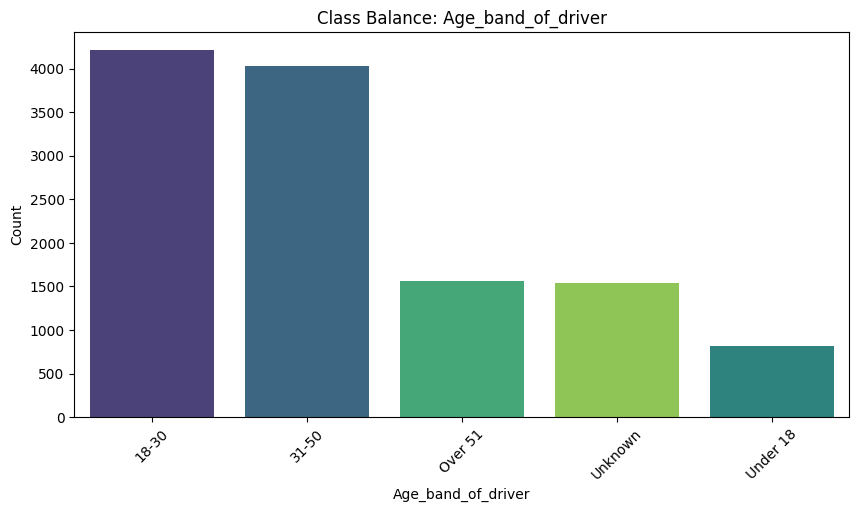


--- Distribution for Sex_of_driver ---
Sex_of_driver
Male      92.819543
Female     5.724626
Other      1.455832
Name: proportion, dtype: float64


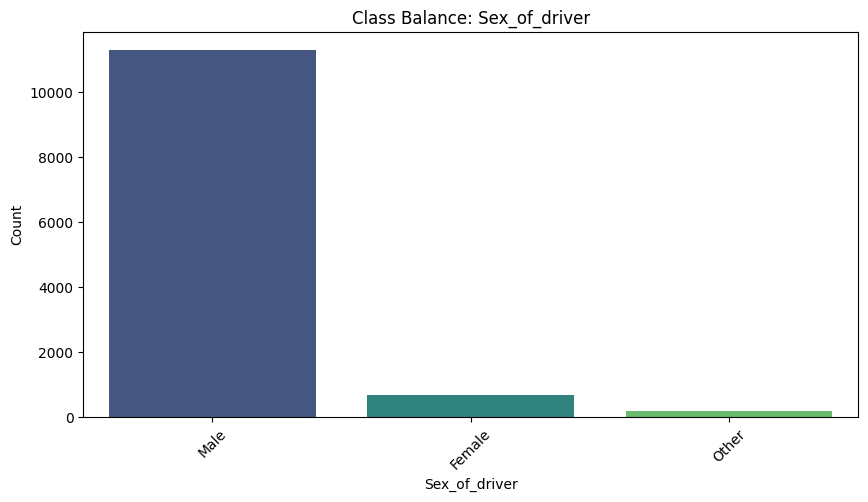


--- Distribution for Educational_level ---
Educational_level
Junior high school    61.868728
Elementary school     17.593354
High school            9.006416
Unknown                6.802106
Other                  4.729396
Name: proportion, dtype: float64


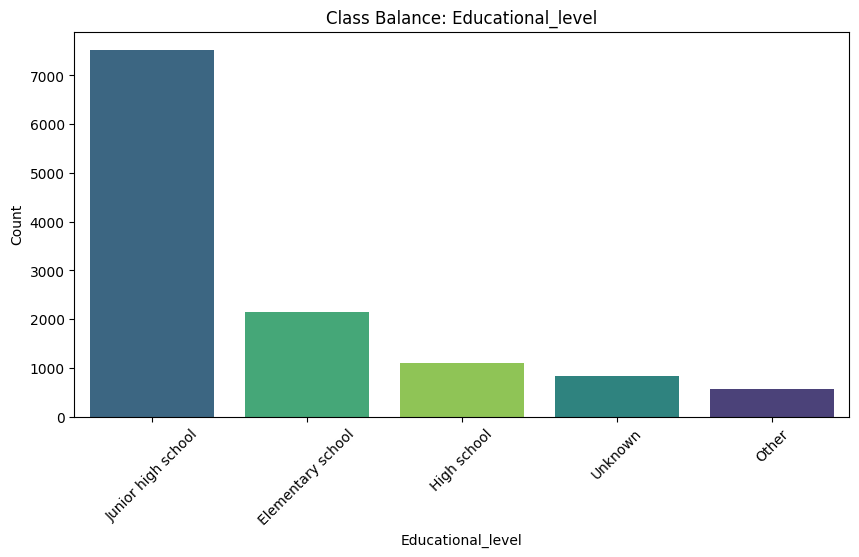


--- Distribution for Vehicle_driver_relation ---
Vehicle_driver_relation
Employee    78.244777
Owner       15.948347
Other        5.806876
Name: proportion, dtype: float64


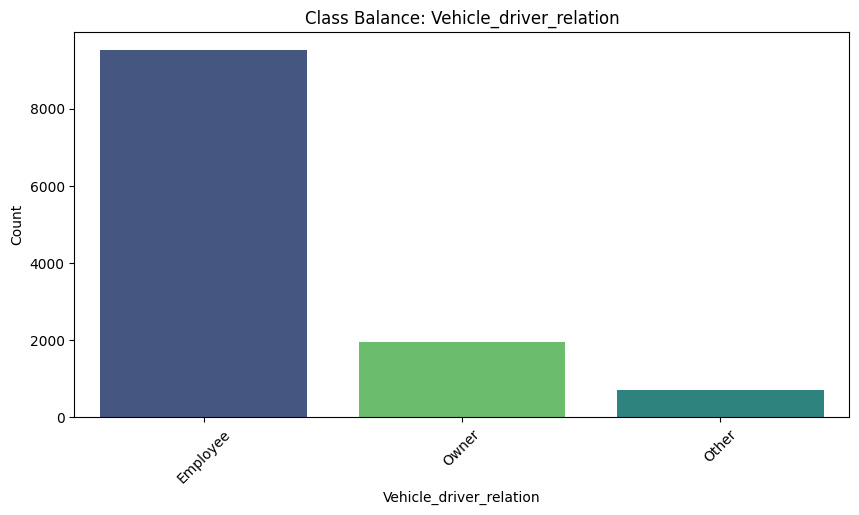


--- Distribution for Driving_experience ---
Driving_experience
5-10yr        27.323573
2-5yr         21.113670
Above 10yr    18.366508
1-2yr         14.270439
Below 1yr     10.980424
Unknown        6.711630
Other          1.233756
Name: proportion, dtype: float64


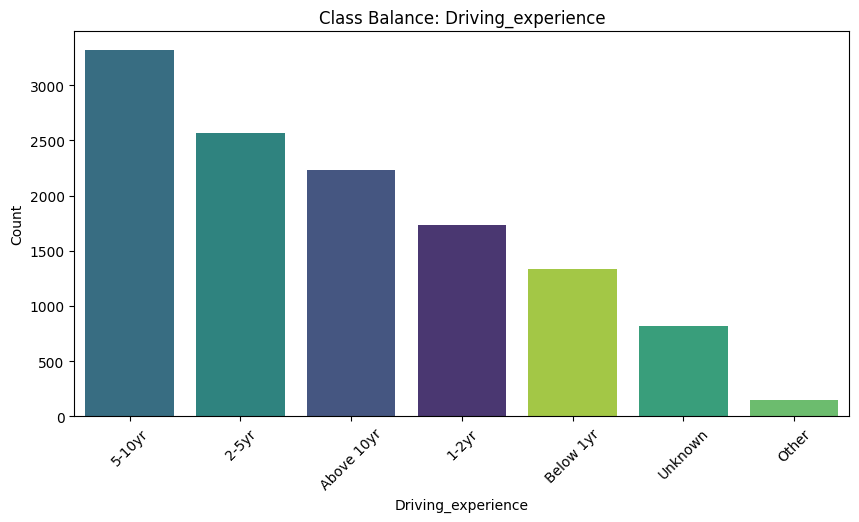


--- Distribution for Type_of_vehicle ---
Type_of_vehicle
Other                30.572463
Automobile           26.032242
Lorry (41?100Q)      17.766080
Unknown               7.723310
Pick up upto 10Q      6.547129
Public (12 seats)     5.773976
Stationwagen          5.584800
Name: proportion, dtype: float64


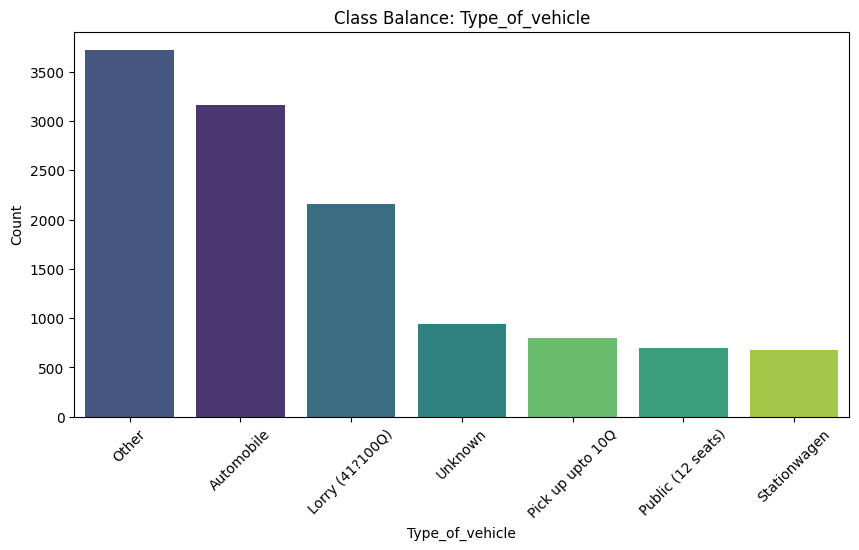


--- Distribution for Owner_of_vehicle ---
Owner_of_vehicle
Owner           84.931732
Governmental     8.430663
Other            6.637605
Name: proportion, dtype: float64


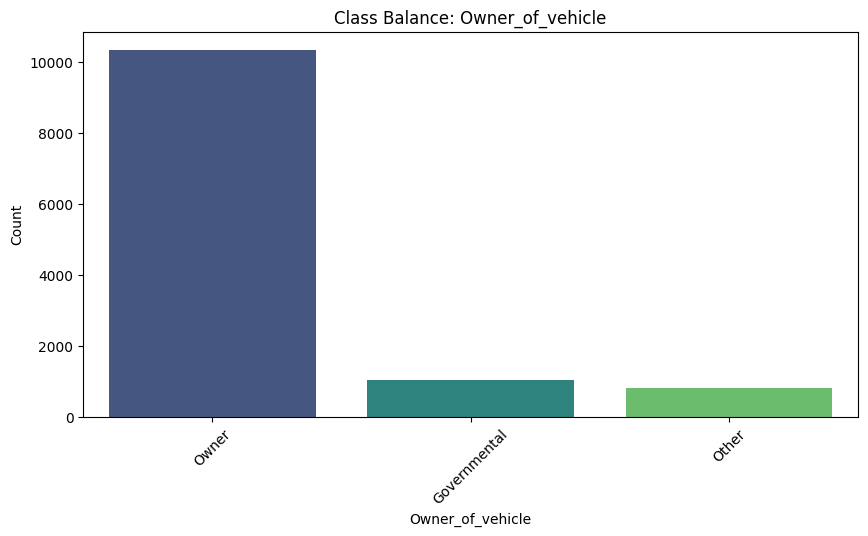


--- Distribution for Service_year_of_vehicle ---
Service_year_of_vehicle
Unknown       55.305149
2-5yrs        14.508965
Above 10yr    10.791249
5-10yrs       10.396447
1-2yr          6.728080
Other          2.270110
Name: proportion, dtype: float64


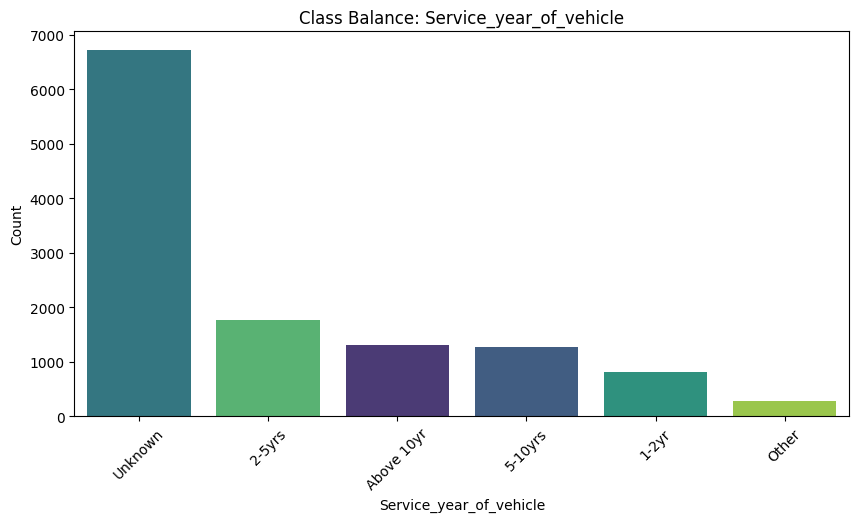


--- Distribution for Defect_of_vehicle ---
Defect_of_vehicle
No defect    63.102484
Unknown      35.976312
Other         0.921204
Name: proportion, dtype: float64


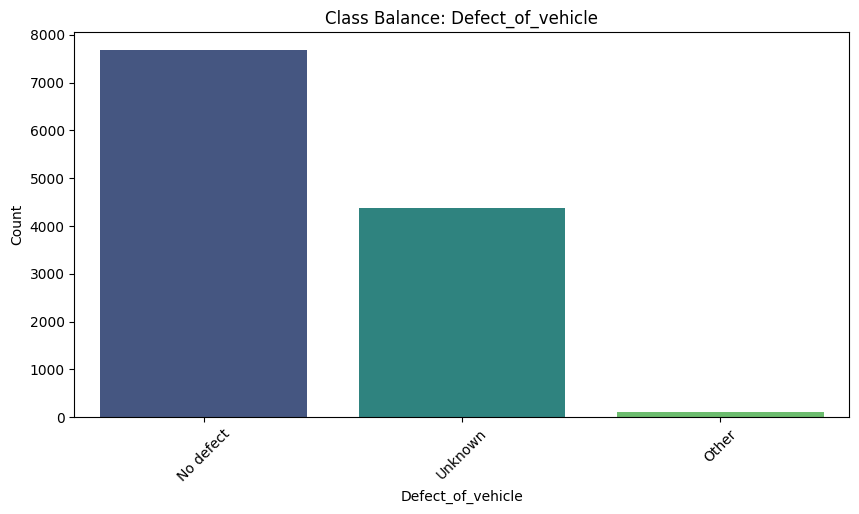


--- Distribution for Area_accident_occured ---
Area_accident_occured
Other                46.660635
Office areas         28.063826
Residential areas    16.639250
 Church areas         8.636289
Name: proportion, dtype: float64


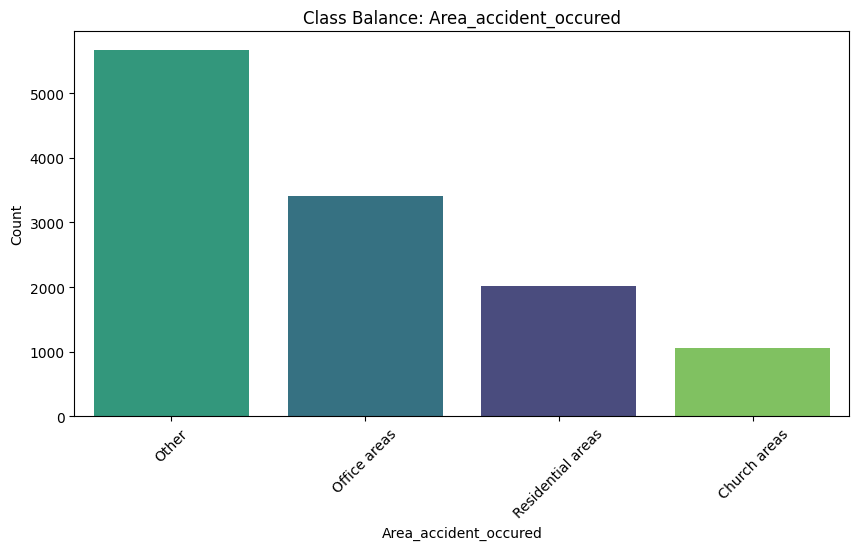


--- Distribution for Lanes_or_Medians ---
Lanes_or_Medians
Two-way (divided with broken lines road marking)    35.877611
Undivided Two way                                   30.712288
other                                               13.472611
Double carriageway (median)                          8.331962
One way                                              6.851456
Other                                                4.754071
Name: proportion, dtype: float64


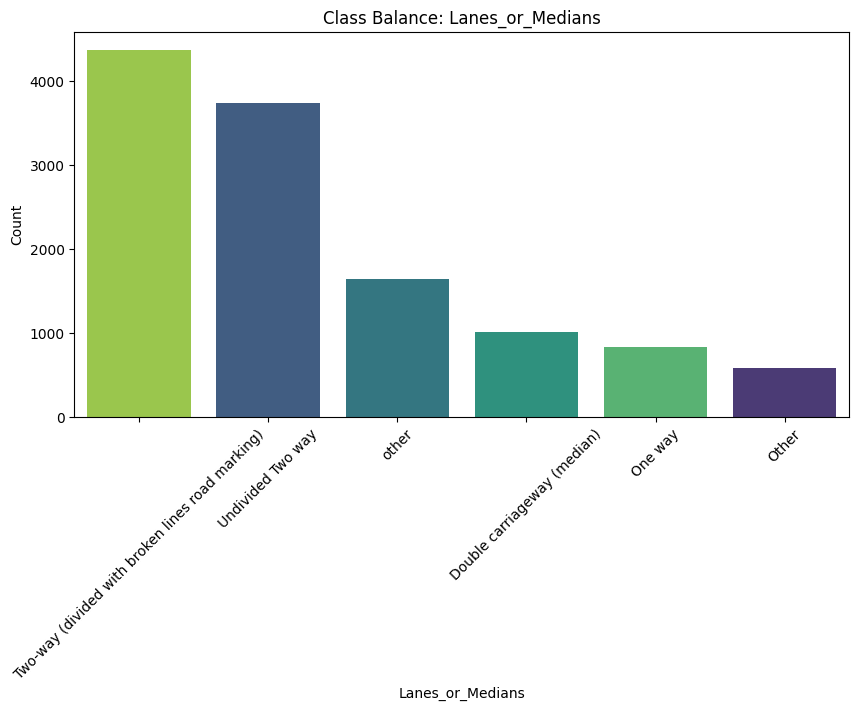


--- Distribution for Road_allignment ---
Road_allignment
Tangent road with flat terrain    84.874157
Other                             15.125843
Name: proportion, dtype: float64


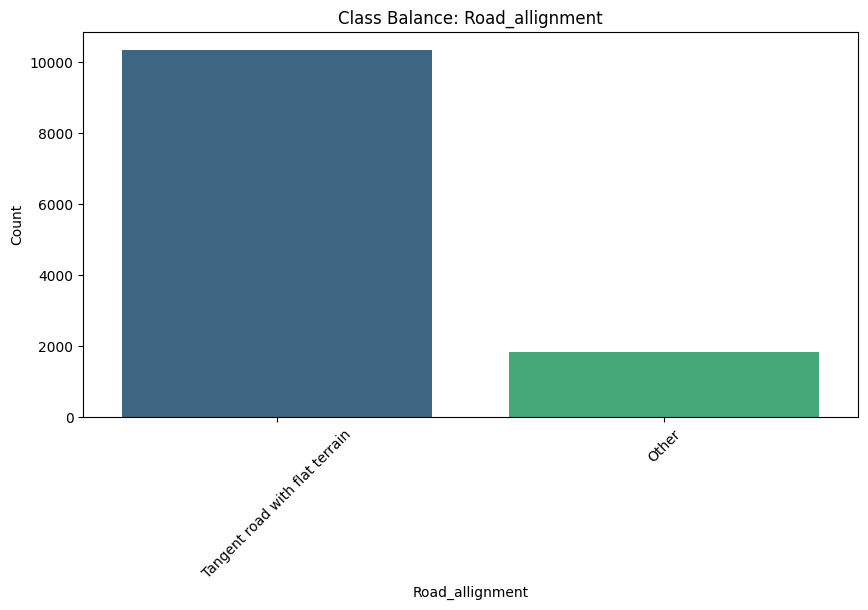


--- Distribution for Types_of_Junction ---
Types_of_Junction
Y Shape        36.930416
No junction    30.975489
Crossing       17.807205
Unknown         8.710314
Other           5.576575
Name: proportion, dtype: float64


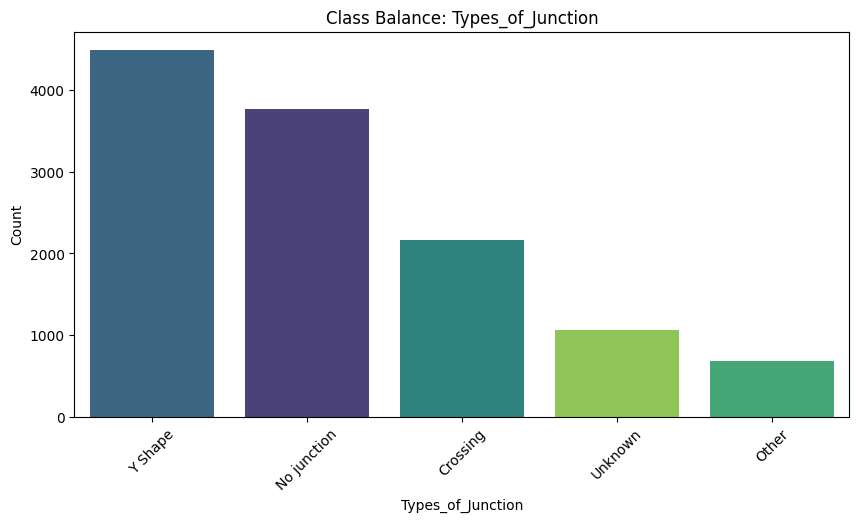


--- Distribution for Road_surface_type ---
Road_surface_type
Asphalt roads    91.692713
Other             8.307287
Name: proportion, dtype: float64


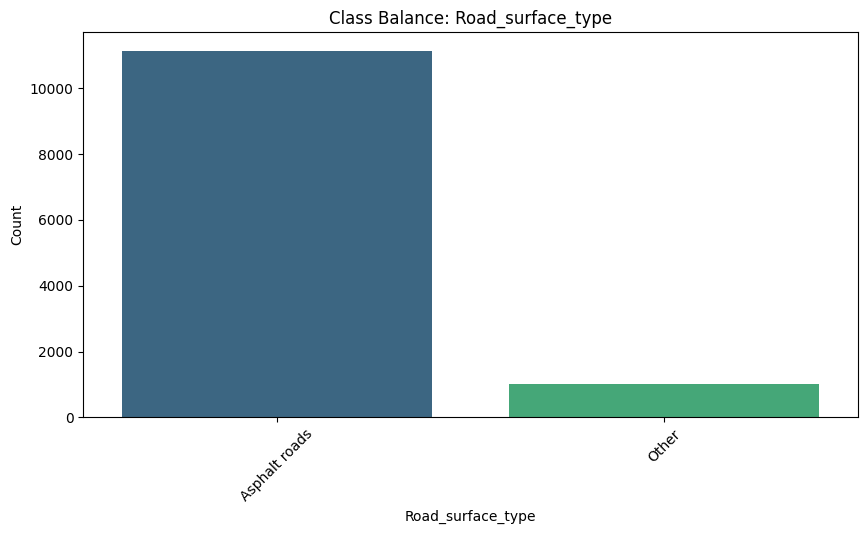


--- Distribution for Road_surface_conditions ---
Road_surface_conditions
Dry            75.826616
Wet or damp    23.581181
Other           0.592203
Name: proportion, dtype: float64


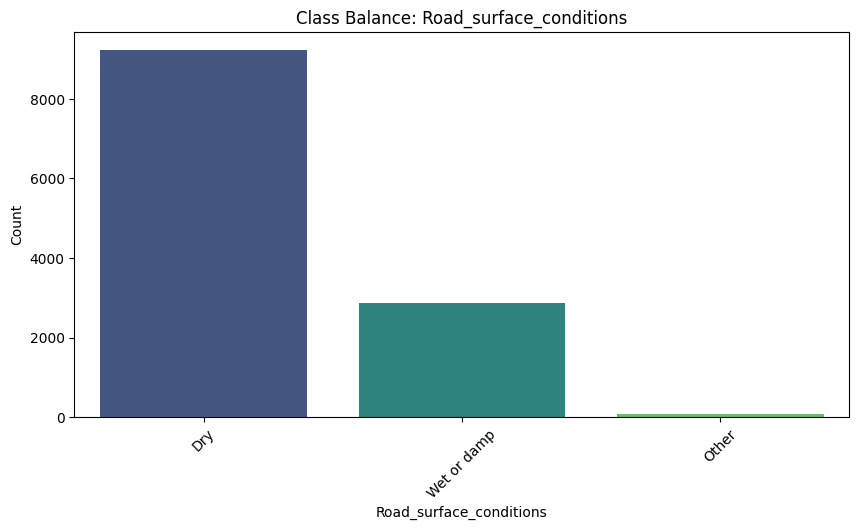


--- Distribution for Light_conditions ---
Light_conditions
Daylight                 71.648297
Darkness - lights lit    26.484619
Other                     1.867083
Name: proportion, dtype: float64


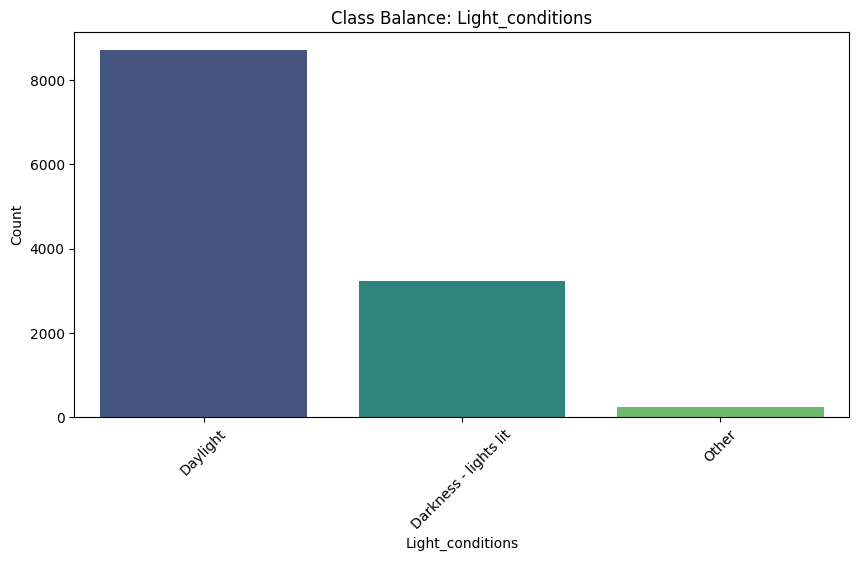


--- Distribution for Weather_conditions ---
Weather_conditions
Normal     81.658167
Raining    10.758348
Other       7.583484
Name: proportion, dtype: float64


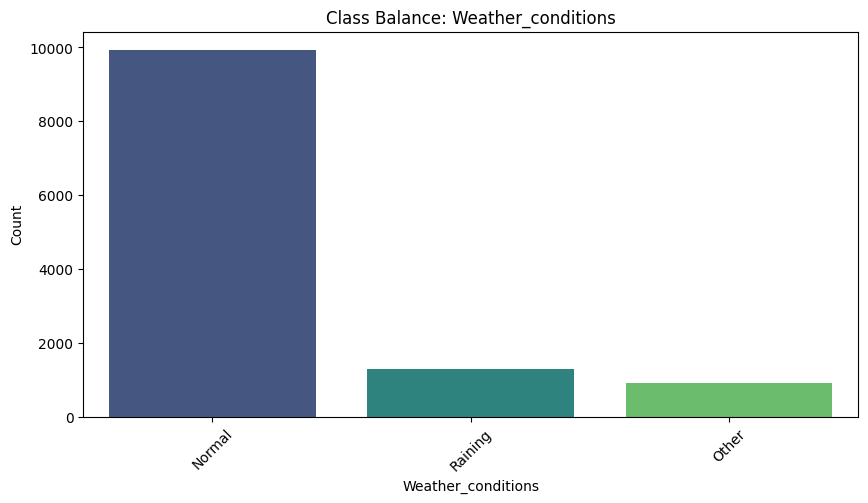


--- Distribution for Type_of_collision ---
Type_of_collision
Vehicle with vehicle collision     71.311071
Collision with roadside objects    14.492515
Collision with pedestrians          7.188682
Other                               7.007732
Name: proportion, dtype: float64


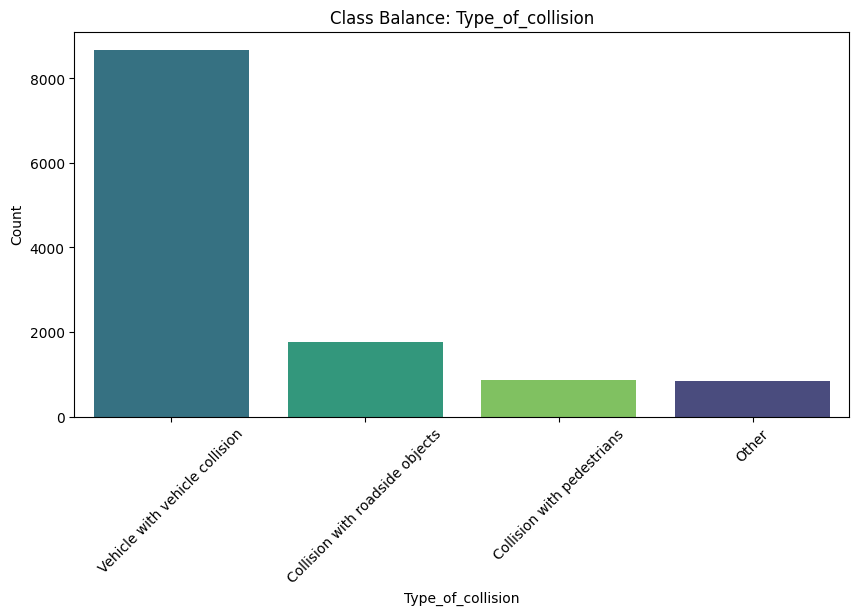


--- Distribution for Vehicle_movement ---
Vehicle_movement
Going straight     66.285573
Other              25.711466
Moving Backward     8.002961
Name: proportion, dtype: float64


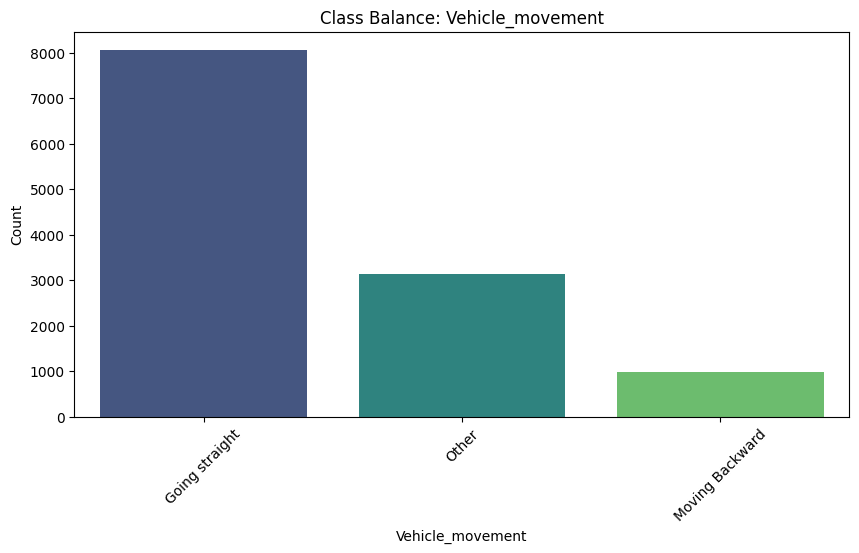


--- Distribution for Casualty_class ---
Casualty_class
Driver or rider    40.080605
Unknown            36.149038
Pedestrian         13.341010
Passenger          10.429347
Name: proportion, dtype: float64


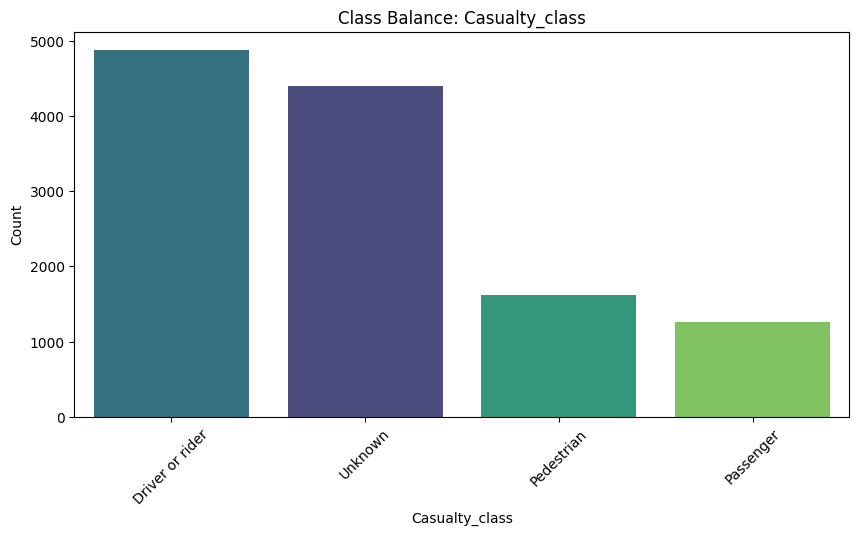


--- Distribution for Sex_of_casualty ---
Sex_of_casualty
Male       42.539891
Unknown    36.149038
Female     21.311071
Name: proportion, dtype: float64


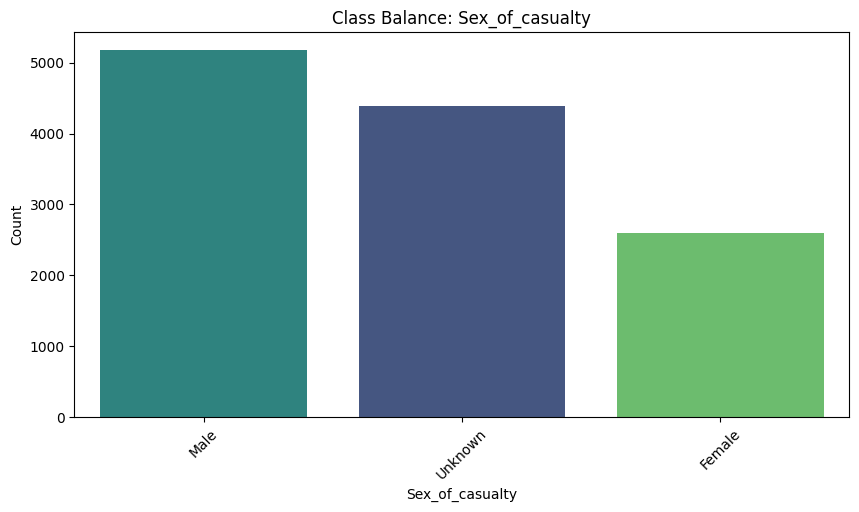


--- Distribution for Age_band_of_casualty ---
Age_band_of_casualty
Unknown     36.149038
18-30       25.448265
31-50       19.970390
Under 18     8.405988
Over 51      8.044086
Other        1.982234
Name: proportion, dtype: float64


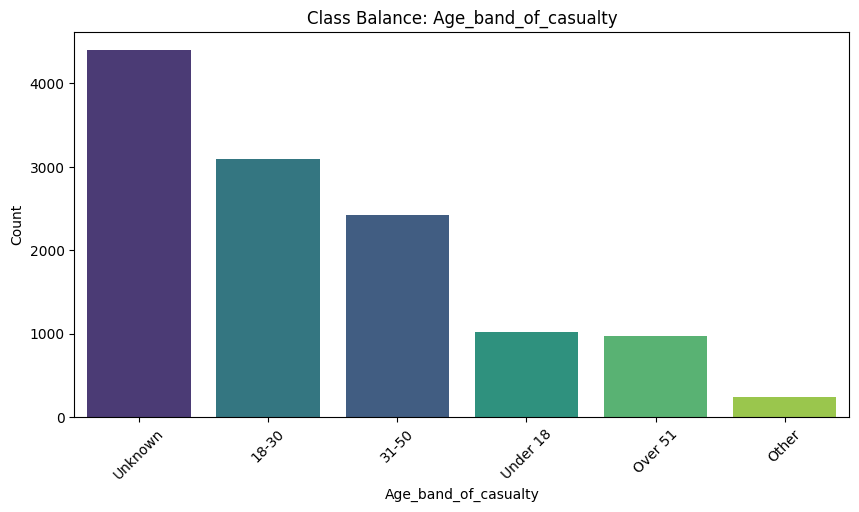


--- Distribution for Casualty_severity ---
Casualty_severity
3          57.377858
Unknown    36.149038
2           6.259253
Other       0.213851
Name: proportion, dtype: float64


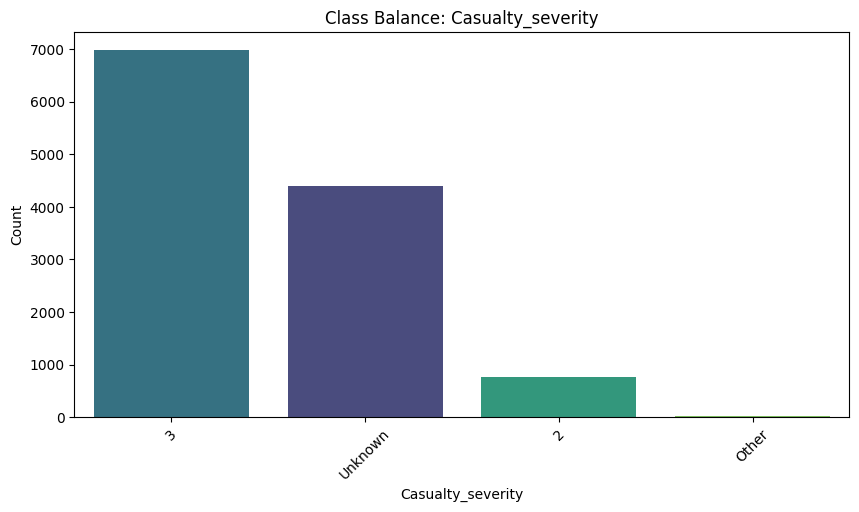


--- Distribution for Work_of_casuality ---
Work_of_casuality
Driver           47.894391
Unknown          26.114493
Self-employed    16.589900
Other             9.401217
Name: proportion, dtype: float64


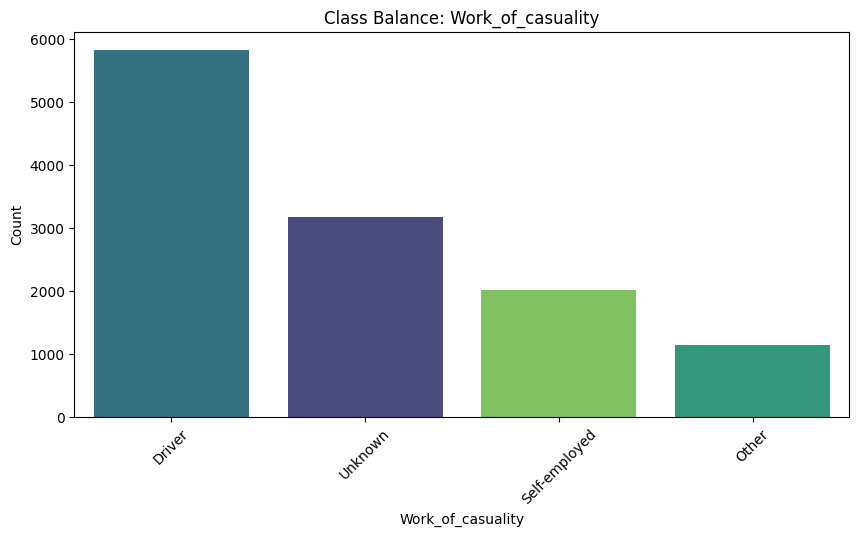


--- Distribution for Fitness_of_casuality ---
Fitness_of_casuality
Normal     77.989801
Unknown    21.417996
Other       0.592203
Name: proportion, dtype: float64


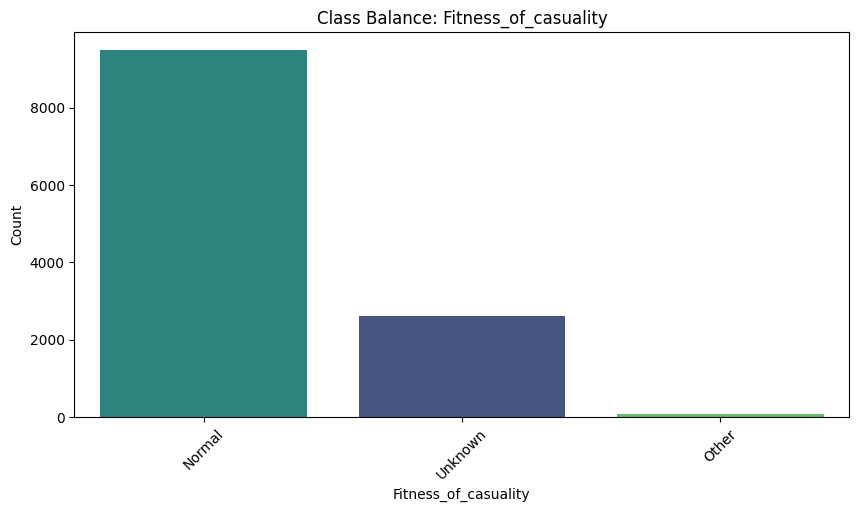


--- Distribution for Pedestrian_movement ---
Pedestrian_movement
Not a Pedestrian    92.515216
Other                7.484784
Name: proportion, dtype: float64


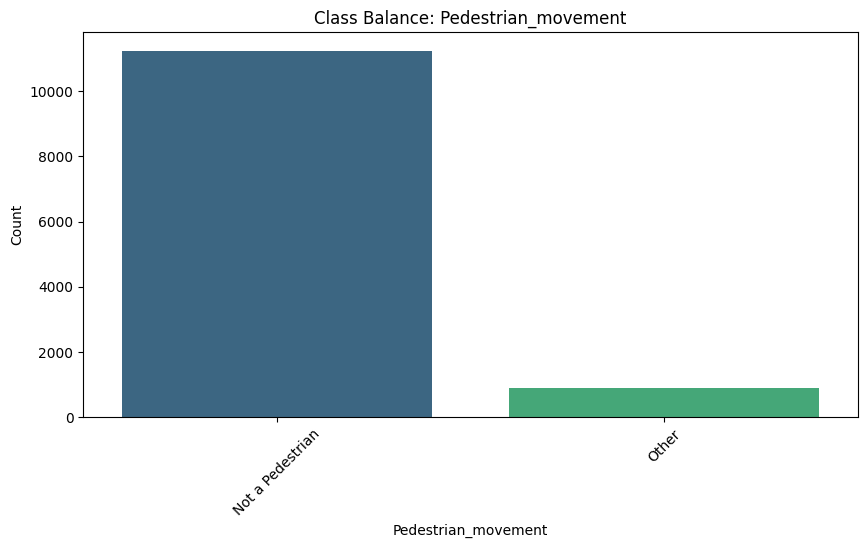


--- Distribution for Cause_of_accident ---
Cause_of_accident
Other                         18.687284
No distancing                 18.448758
Changing lane to the right    14.681691
Changing lane to the left     11.983879
Driving carelessly            11.350551
No priority to vehicle         9.820694
Moving Backward                9.138016
No priority to pedestrian      5.889127
Name: proportion, dtype: float64


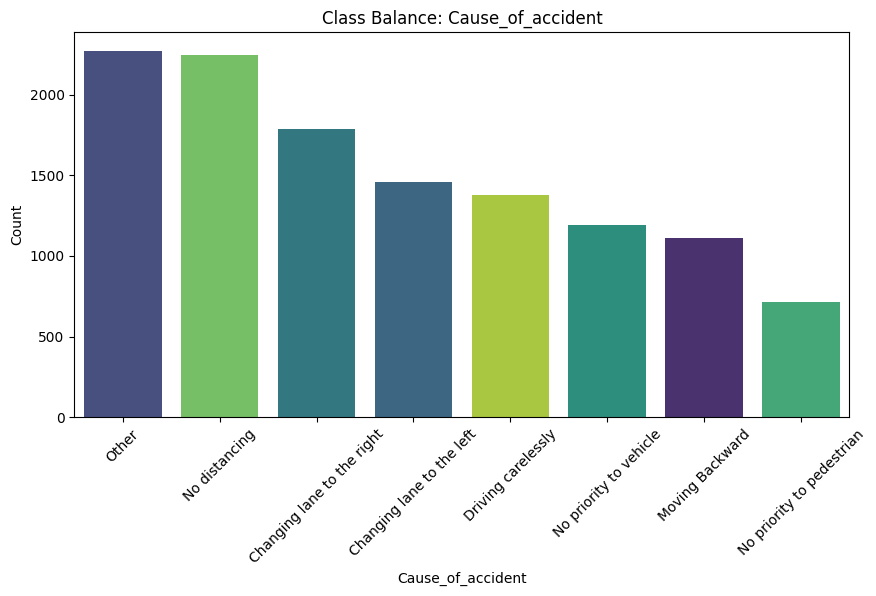


--- Distribution for Accident_severity ---
Accident_severity
Slight Injury     85.66376
Serious Injury    14.33624
Name: proportion, dtype: float64


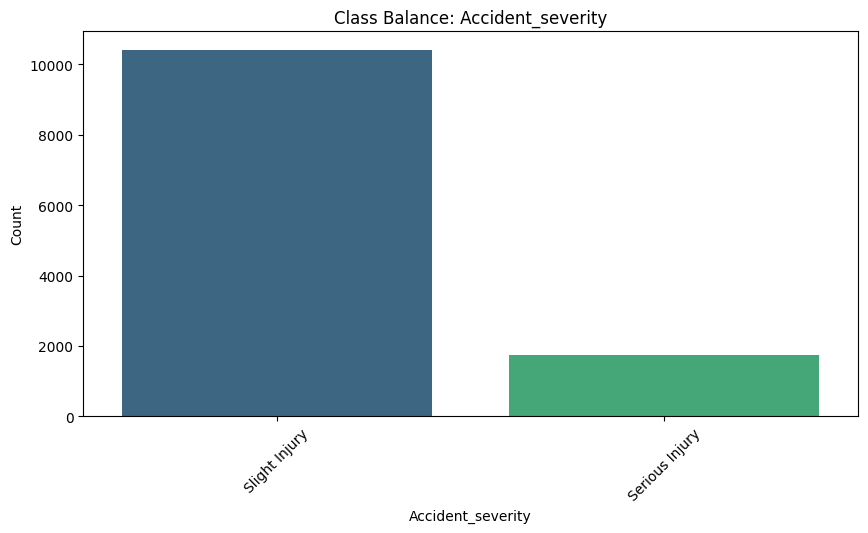

In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns

for cat in categorical_cols:
    print(f"\n--- Distribution for {cat} ---")
    print(df[cat].value_counts(normalize=True) * 100)

    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df, 
        x=cat, 
        hue=cat, 
        palette='viridis', 
        legend=False,
        order=df[cat].value_counts().index
    )
    
    plt.title(f'Class Balance: {cat}')
    plt.xticks(rotation=45)
    plt.xlabel(cat)
    plt.ylabel('Count')
    plt.show()


In [14]:
numeric_features = ['Number_of_vehicles_involved', 'Number_of_casualties']
nominal_features =categorical_cols.tolist()
nominal_features.remove('Accident_severity')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)
    ]
)

X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

# Encode target: Serious vs Slight (0 and 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

#Apply Transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Handle Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print(f"Classes found: {le.classes_}")
print(f"Original shape: {X_train_processed.shape}")
print(f"Balanced shape: {X_train_balanced.shape}")


Classes found: ['Serious Injury' 'Slight Injury']
Original shape: (9726, 120)
Balanced shape: (16664, 120)


In [15]:
X_train_tensor = torch.tensor(X_train_balanced, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_balanced, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [16]:
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Simple ANN with BCEWithLogitsLoss()
#### on SGD, Momentum, Adam, RMSProp, Adagrad

In [17]:
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleANN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1) 
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        return self.output(x)

In [18]:
import copy

In [19]:
optimizers_dict = {
    "SGD": lambda params: torch.optim.SGD(params, lr=0.01),
    "Momentum": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam": lambda params: torch.optim.Adam(params, lr=0.001),
    "RMSprop": lambda params: torch.optim.RMSprop(params, lr=0.001),
    "Adagrad": lambda params: torch.optim.Adagrad(params, lr=0.01)
}

loss_history = {}
trained_models = {}
input_dim = X_train_balanced.shape[1]
epochs = 20
criterion = nn.BCEWithLogitsLoss()

for name, opt_func in optimizers_dict.items():
    print(f"Training with {name}...")
    model = SimpleANN(input_dim)
    optimizer = opt_func(model.parameters())
    history = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y.view(-1, 1).float())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        history.append(epoch_loss / len(train_loader))
    
    loss_history[name] = history
    trained_models[name] = copy.deepcopy(model)


Training with SGD...
Training with Momentum...
Training with Adam...
Training with RMSprop...
Training with Adagrad...


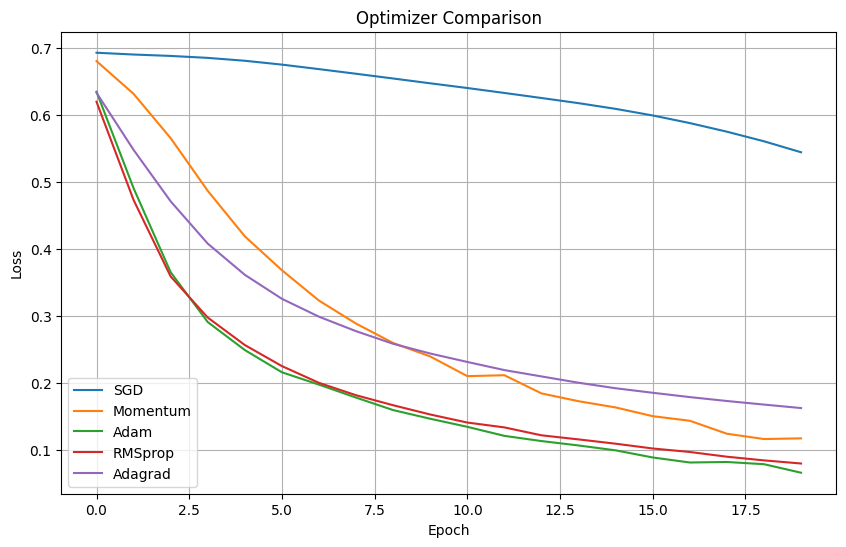

In [20]:
# --- 4. Visualization ---
plt.figure(figsize=(10, 6))
for name, losses in loss_history.items():
    plt.plot(losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
print("\n" + "="*30)
print("FINAL EVALUATION PER OPTIMIZER")
print("="*30)

for name, model in trained_models.items():
    model.eval() 
    
    with torch.no_grad():
        logits = model(X_test_tensor)
        
        # Convert logits to binary predictions (0 or 1)
        # For BCEWithLogits, if logit > 0, probability is > 0.5
        y_pred = (logits > 0).int().numpy().flatten()
        y_true = y_test_tensor.numpy()

    # Metrics calculation
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nOPTIMIZER: {name} | Accuracy: {acc:.2%}")
    print(cm)
    # print(classification_report(y_true, y_pred, target_names=le.classes_))    
    print("-" * 30)


FINAL EVALUATION PER OPTIMIZER

OPTIMIZER: SGD | Accuracy: 63.03%
[[ 173  176]
 [ 723 1360]]
------------------------------

OPTIMIZER: Momentum | Accuracy: 76.56%
[[  84  265]
 [ 305 1778]]
------------------------------

OPTIMIZER: Adam | Accuracy: 76.15%
[[  71  278]
 [ 302 1781]]
------------------------------

OPTIMIZER: RMSprop | Accuracy: 74.22%
[[  85  264]
 [ 363 1720]]
------------------------------

OPTIMIZER: Adagrad | Accuracy: 75.45%
[[  84  265]
 [ 332 1751]]
------------------------------


# Simple ANN with BCELoss
#### on SGD, Momentum, Adam, RMSProp, Adagrad

In [22]:
class SimpleANN2(nn.Module):
    def __init__(self, input_dim):
        super(SimpleANN2, self).__init__() 
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1) 
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        return self.sigmoid(self.output(x))

In [23]:
loss_history = {}
trained_models = {}
input_dim = X_train_balanced.shape[1]
epochs = 20
criterion = nn.BCELoss()

for name, opt_func in optimizers_dict.items():
    print(f"Training with {name}...")
    model = SimpleANN2(input_dim)
    optimizer = opt_func(model.parameters())
    history = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            outputs = model(batch_X) 
            
            loss = criterion(outputs, batch_y.view(-1, 1).float())
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        history.append(epoch_loss / len(train_loader))
    
    loss_history[name] = history
    trained_models[name] = copy.deepcopy(model)

Training with SGD...
Training with Momentum...
Training with Adam...
Training with RMSprop...
Training with Adagrad...


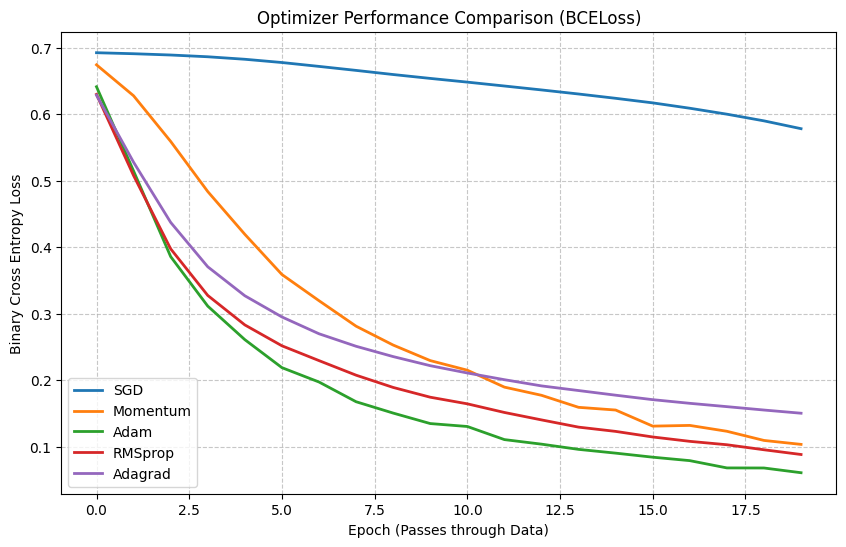

In [24]:
plt.figure(figsize=(10, 6))

for name, losses in loss_history.items():
    plt.plot(losses, label=name, linewidth=2)

plt.xlabel("Epoch (Passes through Data)")
plt.ylabel("Binary Cross Entropy Loss") 
plt.title("Optimizer Performance Comparison (BCELoss)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
print("\n" + "="*30)
print("FINAL EVALUATION PER OPTIMIZER (BCE Version)")
print("="*30)

for name, model in trained_models.items():
    model.eval() 
    
    with torch.no_grad():
        # 1. Get probabilities (Model now outputs 0 to 1 because of Sigmoid)
        probs = model(X_test_tensor)
        
        # Convert probabilities to binary predictions (0 or 1)
        # Threshold is now 0.5 for standard BCE
        y_pred = (probs > 0.5).int().numpy().flatten()
        y_true = y_test_tensor.numpy()

    # Metrics calculation
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\nOPTIMIZER: {name} | Accuracy: {acc:.2%}")
    print(cm)
    # print(classification_report(y_true, y_pred, target_names=le.classes_))    
    print("-" * 30)


FINAL EVALUATION PER OPTIMIZER (BCE Version)

OPTIMIZER: SGD | Accuracy: 64.10%
[[ 170  179]
 [ 694 1389]]
------------------------------

OPTIMIZER: Momentum | Accuracy: 73.97%
[[  77  272]
 [ 361 1722]]
------------------------------

OPTIMIZER: Adam | Accuracy: 79.07%
[[  47  302]
 [ 207 1876]]
------------------------------

OPTIMIZER: RMSprop | Accuracy: 73.40%
[[  75  274]
 [ 373 1710]]
------------------------------

OPTIMIZER: Adagrad | Accuracy: 72.20%
[[  94  255]
 [ 421 1662]]
------------------------------


In [26]:
from IPython import display

# SimpleANN with live Training vs validation loss
#### with SGD and BCEWithLogitsLoss

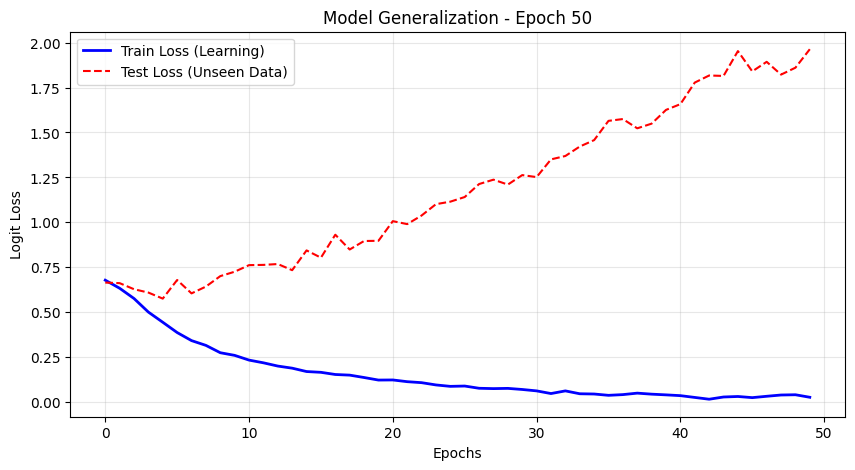

Evaluation Complete!


In [27]:
model = SimpleANN(input_dim)
criterion = nn.BCEWithLogitsLoss() # Logit Loss
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train_losses = []
test_losses = []

# --- 3. Training Loop with Live Test Plotting ---
plt.figure(figsize=(10, 5))

for epoch in range(50):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    
    # --- TEST PHASE (Evaluation) ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
    
    # Store average losses per batch
    train_losses.append(running_train_loss / len(train_loader))
    test_losses.append(running_test_loss / len(test_loader))

    # --- LIVE PLOTTING ---
    display.clear_output(wait=True)
    plt.clf()
    plt.plot(train_losses, label='Train Loss (Learning)', color='blue', linewidth=2)
    plt.plot(test_losses, label='Test Loss (Unseen Data)', color='red', linestyle='--')
    plt.xlabel('Epochs')
    plt.ylabel('Logit Loss')
    plt.title(f'Model Generalization - Epoch {epoch+1}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    display.display(plt.gcf())

plt.close() # Prevents double plotting at the end
print("Evaluation Complete!")